In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 불러오기
train_cn7 = pd.read_csv(
    r"C:\Users\Administrator\Desktop\kamp\1. 사출성형기 AI 데이터셋\1. 사출성형기 AI 데이터셋\moldset_labeled_cn7.csv"
)
train_rg3 = pd.read_csv(
    r"C:\Users\Administrator\Desktop\kamp\1. 사출성형기 AI 데이터셋\1. 사출성형기 AI 데이터셋\moldset_labeled_rg3.csv"
)

# 공통 설정
TARGET = "PassOrFail"
ID_COLS = [c for c in ["Unnamed: 0"] if c in train_cn7.columns]
DATASETS = {"CN7": train_cn7, "RG3": train_rg3}

# Target / ID를 제외한 실제 설명변수 목록
FEATURE_COLS = [c for c in train_cn7.columns if c not in [TARGET] + ID_COLS]
NUMERIC_COLS = train_cn7[FEATURE_COLS].select_dtypes(include=np.number).columns.tolist()
CATEGORICAL_COLS = train_cn7[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()

print("CN7 shape:", train_cn7.shape)
print("RG3 shape:", train_rg3.shape)
print("Target:", TARGET)
print("ID 후보:", ID_COLS)
print("설명변수 개수:", len(FEATURE_COLS))


CN7 shape: (1211, 26)
RG3 shape: (1182, 26)
Target: PassOrFail
ID 후보: ['Unnamed: 0']
설명변수 개수: 24


# #1 데이터 기본 구조 확인

### 1) 데이터 크기 shape

- 데이터셋의 행/열 규모를 확인합니다.


In [2]:
# CN7 데이터의 행(row), 열(column) 개수 확인
train_cn7.shape


(1211, 26)

In [3]:
# RG3 데이터의 행(row), 열(column) 개수 확인
train_rg3.shape


(1182, 26)

### 2) 컬럼명 확인

- 분석에 사용되는 변수명을 확인합니다.


In [4]:
# CN7 컬럼명 확인
train_cn7.columns.tolist()


['Unnamed: 0',
 'PassOrFail',
 'Injection_Time',
 'Filling_Time',
 'Plasticizing_Time',
 'Cycle_Time',
 'Clamp_Close_Time',
 'Cushion_Position',
 'Plasticizing_Position',
 'Clamp_Open_Position',
 'Max_Injection_Speed',
 'Max_Screw_RPM',
 'Average_Screw_RPM',
 'Max_Injection_Pressure',
 'Max_Switch_Over_Pressure',
 'Max_Back_Pressure',
 'Average_Back_Pressure',
 'Barrel_Temperature_1',
 'Barrel_Temperature_2',
 'Barrel_Temperature_3',
 'Barrel_Temperature_4',
 'Barrel_Temperature_5',
 'Barrel_Temperature_6',
 'Hopper_Temperature',
 'Mold_Temperature_3',
 'Mold_Temperature_4']

In [5]:
# RG3 컬럼명 확인
train_rg3.columns.tolist()


['Unnamed: 0',
 'PassOrFail',
 'Injection_Time',
 'Filling_Time',
 'Plasticizing_Time',
 'Cycle_Time',
 'Clamp_Close_Time',
 'Cushion_Position',
 'Plasticizing_Position',
 'Clamp_Open_Position',
 'Max_Injection_Speed',
 'Max_Screw_RPM',
 'Average_Screw_RPM',
 'Max_Injection_Pressure',
 'Max_Switch_Over_Pressure',
 'Max_Back_Pressure',
 'Average_Back_Pressure',
 'Barrel_Temperature_1',
 'Barrel_Temperature_2',
 'Barrel_Temperature_3',
 'Barrel_Temperature_4',
 'Barrel_Temperature_5',
 'Barrel_Temperature_6',
 'Hopper_Temperature',
 'Mold_Temperature_3',
 'Mold_Temperature_4']

### 3) 데이터 타입 확인

- 수치형/문자형 등 실제 저장 타입을 확인합니다.


In [6]:
# CN7 컬럼별 데이터 타입과 결측치 여부 확인
train_cn7.info()


<class 'pandas.DataFrame'>
RangeIndex: 1211 entries, 0 to 1210
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                1211 non-null   int64  
 1   PassOrFail                1211 non-null   int64  
 2   Injection_Time            1211 non-null   float64
 3   Filling_Time              1211 non-null   float64
 4   Plasticizing_Time         1211 non-null   float64
 5   Cycle_Time                1211 non-null   float64
 6   Clamp_Close_Time          1211 non-null   float64
 7   Cushion_Position          1211 non-null   float64
 8   Plasticizing_Position     1211 non-null   float64
 9   Clamp_Open_Position       1211 non-null   float64
 10  Max_Injection_Speed       1211 non-null   float64
 11  Max_Screw_RPM             1211 non-null   float64
 12  Average_Screw_RPM         1211 non-null   float64
 13  Max_Injection_Pressure    1211 non-null   float64
 14  Max_Switch_Over_Pre

In [7]:
# RG3 컬럼별 데이터 타입과 결측치 여부 확인
train_rg3.info()


<class 'pandas.DataFrame'>
RangeIndex: 1182 entries, 0 to 1181
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                1182 non-null   int64  
 1   PassOrFail                1182 non-null   int64  
 2   Injection_Time            1182 non-null   float64
 3   Filling_Time              1182 non-null   float64
 4   Plasticizing_Time         1182 non-null   float64
 5   Cycle_Time                1182 non-null   float64
 6   Clamp_Close_Time          1182 non-null   float64
 7   Cushion_Position          1182 non-null   float64
 8   Plasticizing_Position     1182 non-null   float64
 9   Clamp_Open_Position       1182 non-null   float64
 10  Max_Injection_Speed       1182 non-null   float64
 11  Max_Screw_RPM             1182 non-null   float64
 12  Average_Screw_RPM         1182 non-null   float64
 13  Max_Injection_Pressure    1182 non-null   float64
 14  Max_Switch_Over_Pre

### 4) 수치형 / 범주형 / 날짜형 변수 구분

- 수치 계산이 가능한 공정·센서 변수를 확인합니다.


#### 4-1) 수치형 변수 확인

- 수치 계산이 가능한 공정·센서 변수를 확인합니다.


In [8]:
# Target / ID를 제외한 수치형 설명변수 확인
numeric_cols = train_cn7[FEATURE_COLS].select_dtypes(include=np.number).columns.tolist()
numeric_cols


['Injection_Time',
 'Filling_Time',
 'Plasticizing_Time',
 'Cycle_Time',
 'Clamp_Close_Time',
 'Cushion_Position',
 'Plasticizing_Position',
 'Clamp_Open_Position',
 'Max_Injection_Speed',
 'Max_Screw_RPM',
 'Average_Screw_RPM',
 'Max_Injection_Pressure',
 'Max_Switch_Over_Pressure',
 'Max_Back_Pressure',
 'Average_Back_Pressure',
 'Barrel_Temperature_1',
 'Barrel_Temperature_2',
 'Barrel_Temperature_3',
 'Barrel_Temperature_4',
 'Barrel_Temperature_5',
 'Barrel_Temperature_6',
 'Hopper_Temperature',
 'Mold_Temperature_3',
 'Mold_Temperature_4']

#### 4-2) 범주형 변수 확인

- 카테고리 형태로 처리해야 할 변수가 있는지 확인합니다.


In [9]:
# Target / ID를 제외한 범주형 설명변수 확인
categorical_cols = train_cn7[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
categorical_cols


[]

#### 4-3) 날짜형 변수 확인

- 실제 날짜/타임스탬프 변수가 있는지 확인합니다.


In [10]:
# 실제 datetime 타입 컬럼 확인
# 현재 데이터의 *_Time 컬럼은 '시간 길이'를 의미하는 수치형 변수이므로 날짜형으로 처리하지 않음
date_cols = train_cn7.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
date_cols


[]

### 5) 각 컬럼 의미 정리

- 각 공정·센서 변수의 의미를 분석용으로 정리합니다.


In [11]:
# 사출 공정 컬럼의 의미 정리
column_meanings = {
    "Unnamed: 0": "원본 CSV 저장 과정에서 생성된 행 인덱스 성격의 컬럼",
    "PassOrFail": "품질 판정 Target (정상/불량)",
    "Injection_Time": "사출(Injection) 공정 시간",
    "Filling_Time": "금형 내부 충전(Filling) 시간",
    "Plasticizing_Time": "수지를 가소화하는 데 걸린 시간",
    "Cycle_Time": "제품 1개 생산에 소요된 전체 사이클 시간",
    "Clamp_Close_Time": "금형을 닫는 데 걸린 시간",
    "Cushion_Position": "사출 종료 후 스크류의 쿠션 위치",
    "Plasticizing_Position": "가소화 완료 시 스크류 위치",
    "Clamp_Open_Position": "금형 개방 위치",
    "Max_Injection_Speed": "최대 사출 속도",
    "Max_Screw_RPM": "스크류 최대 회전속도(RPM)",
    "Average_Screw_RPM": "스크류 평균 회전속도(RPM)",
    "Max_Injection_Pressure": "최대 사출 압력",
    "Max_Switch_Over_Pressure": "보압 전환 시점의 최대 압력",
    "Max_Back_Pressure": "최대 배압",
    "Average_Back_Pressure": "평균 배압",
    "Barrel_Temperature_1": "배럴 구간 1 온도",
    "Barrel_Temperature_2": "배럴 구간 2 온도",
    "Barrel_Temperature_3": "배럴 구간 3 온도",
    "Barrel_Temperature_4": "배럴 구간 4 온도",
    "Barrel_Temperature_5": "배럴 구간 5 온도",
    "Barrel_Temperature_6": "배럴 구간 6 온도",
    "Hopper_Temperature": "호퍼 온도",
    "Mold_Temperature_3": "금형 온도 센서 3",
    "Mold_Temperature_4": "금형 온도 센서 4",
}

pd.DataFrame({
    "컬럼": train_cn7.columns,
    "의미": [column_meanings.get(c, "추가 확인 필요") for c in train_cn7.columns],
    "dtype": train_cn7.dtypes.astype(str).values
})


,컬럼,의미,dtype
0,Unnamed: 0,원본 CSV 저장 과정에서 생성된 행 인덱스 성격의 컬럼,int64
1,PassOrFail,품질 판정 Target (정상/불량),int64
2,Injection_Time,사출(Injection) 공정 시간,float64
3,Filling_Time,금형 내부 충전(Filling) 시간,float64
4,Plasticizing_Time,수지를 가소화하는 데 걸린 시간,float64
5,Cycle_Time,제품 1개 생산에 소요된 전체 사이클 시간,float64
6,Clamp_Close_Time,금형을 닫는 데 걸린 시간,float64
7,Cushion_Position,사출 종료 후 스크류의 쿠션 위치,float64
8,Plasticizing_Position,가소화 완료 시 스크류 위치,float64
9,Clamp_Open_Position,금형 개방 위치,float64


### 6) Target / ID / 설명변수 구분

- 예측 대상, 식별용 컬럼, 모델 입력 설명변수를 분리합니다.


In [12]:
# Target 변수 확인
# PassOrFail이 모델이 예측해야 할 품질 판정값
target_col = TARGET
target_col


'PassOrFail'

In [13]:
# ID성 변수 확인
# Unnamed: 0은 각 행마다 거의/완전히 고유한 값이면 모델 입력에서 제외하는 것이 일반적
id_summary = pd.DataFrame({
    "nunique": train_cn7.nunique(),
    "unique_ratio": train_cn7.nunique() / len(train_cn7)
}).sort_values("unique_ratio", ascending=False)

id_summary.head()


,nunique,unique_ratio
Unnamed: 0,1211,1.000000
Hopper_Temperature,47,0.038811
Mold_Temperature_4,41,0.033856
Mold_Temperature_3,39,0.032205
Barrel_Temperature_4,36,0.029727


In [14]:
# 설명변수(X) 목록 확인
# Target과 ID 후보를 제외한 공정/센서 변수
feature_cols = [c for c in train_cn7.columns if c not in [TARGET] + ID_COLS]
feature_cols


['Injection_Time',
 'Filling_Time',
 'Plasticizing_Time',
 'Cycle_Time',
 'Clamp_Close_Time',
 'Cushion_Position',
 'Plasticizing_Position',
 'Clamp_Open_Position',
 'Max_Injection_Speed',
 'Max_Screw_RPM',
 'Average_Screw_RPM',
 'Max_Injection_Pressure',
 'Max_Switch_Over_Pressure',
 'Max_Back_Pressure',
 'Average_Back_Pressure',
 'Barrel_Temperature_1',
 'Barrel_Temperature_2',
 'Barrel_Temperature_3',
 'Barrel_Temperature_4',
 'Barrel_Temperature_5',
 'Barrel_Temperature_6',
 'Hopper_Temperature',
 'Mold_Temperature_3',
 'Mold_Temperature_4']

In [15]:
# CN7과 RG3의 Target / ID / 설명변수 구조가 동일한지 확인
print("Target:", TARGET)
print("ID 후보:", ID_COLS)
print("CN7 설명변수 개수:", len([c for c in train_cn7.columns if c not in [TARGET] + ID_COLS]))
print("RG3 설명변수 개수:", len([c for c in train_rg3.columns if c not in [TARGET] + ID_COLS]))
print("컬럼 구조 동일:", train_cn7.columns.tolist() == train_rg3.columns.tolist())


Target: PassOrFail
ID 후보: ['Unnamed: 0']
CN7 설명변수 개수: 24
RG3 설명변수 개수: 24
컬럼 구조 동일: True


---


# #2 데이터 품질 확인

### 1) 결측치 개수 / 비율

- 누락된 값의 개수와 비율을 확인합니다.


In [16]:
# 데이터셋별 결측치 개수와 비율 확인
for name, df in DATASETS.items():
    missing = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_ratio(%)": df.isna().mean() * 100
    })
    print(f"\n[{name}]")
    display(missing[missing["missing_count"] > 0] if (missing["missing_count"] > 0).any() else missing.head(0))



[CN7]


,missing_count,missing_ratio(%)



[RG3]


,missing_count,missing_ratio(%)


### 2) 완전 중복 행 확인

- 반복 행 또는 반복 조건이 존재하는지 확인합니다.


In [17]:
# 완전히 동일한 행이 반복되는지 확인
for name, df in DATASETS.items():
    full_dup = df.duplicated().sum()
    feature_dup = df.duplicated(subset=FEATURE_COLS).sum()

    print(f"[{name}] 완전 중복 행:", full_dup)
    print(f"[{name}] 설명변수(X) 기준 중복 행:", feature_dup)


[CN7] 완전 중복 행: 0
[CN7] 설명변수(X) 기준 중복 행: 605
[RG3] 완전 중복 행: 0
[RG3] 설명변수(X) 기준 중복 행: 591


### 3) ID성 컬럼 중복 확인

- 반복 행 또는 반복 조건이 존재하는지 확인합니다.


In [18]:
# ID 후보 컬럼의 중복 여부 확인
# ID라면 일반적으로 한 행을 유일하게 식별해야 하므로 duplicated가 없어야 함
for name, df in DATASETS.items():
    print(f"\n[{name}]")
    for col in ID_COLS:
        print(col, "중복 개수:", df[col].duplicated().sum(),
              "| 고유값:", df[col].nunique(),
              "| 전체 행:", len(df))



[CN7]
Unnamed: 0 중복 개수: 0 | 고유값: 1211 | 전체 행: 1211

[RG3]
Unnamed: 0 중복 개수: 0 | 고유값: 1182 | 전체 행: 1182


### 4) 컬럼별 고유값 개수 확인

- 변수별 값의 다양성과 ID성 여부를 확인합니다.


In [19]:
# 컬럼별 고유값 개수와 비율 확인
for name, df in DATASETS.items():
    unique_summary = pd.DataFrame({
        "nunique": df.nunique(dropna=False),
        "unique_ratio(%)": df.nunique(dropna=False) / len(df) * 100
    }).sort_values("nunique")

    print(f"\n[{name}]")
    display(unique_summary)



[CN7]


,nunique,unique_ratio(%)
Clamp_Open_Position,1,0.082576
PassOrFail,2,0.165153
Clamp_Close_Time,3,0.247729
Cushion_Position,5,0.412882
Average_Screw_RPM,7,0.578035
Max_Injection_Pressure,8,0.660611
Max_Screw_RPM,8,0.660611
Cycle_Time,13,1.073493
Plasticizing_Position,13,1.073493
Barrel_Temperature_6,13,1.073493



[RG3]


,nunique,unique_ratio(%)
Clamp_Open_Position,1,0.084602
PassOrFail,2,0.169205
Filling_Time,2,0.169205
Injection_Time,3,0.253807
Clamp_Close_Time,3,0.253807
Max_Screw_RPM,4,0.338409
Average_Screw_RPM,4,0.338409
Cushion_Position,7,0.592217
Max_Injection_Speed,7,0.592217
Plasticizing_Position,8,0.676819


### 5) 상수 컬럼 확인

- 정보량이 없는 상수 또는 거의-상수 변수를 확인합니다.


In [20]:
# 모든 행에서 값이 동일한 상수 컬럼 확인
for name, df in DATASETS.items():
    constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    print(f"[{name}] 상수 컬럼:", constant_cols)


[CN7] 상수 컬럼: ['Clamp_Open_Position']
[RG3] 상수 컬럼: ['Clamp_Open_Position']


### 6) 거의 한 값만 존재하는 컬럼 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [21]:
# 특정 값 하나가 99% 이상을 차지하는 거의-상수 컬럼 확인
for name, df in DATASETS.items():
    near_constant = []
    for col in df.columns:
        top_ratio = df[col].value_counts(dropna=False, normalize=True).iloc[0]
        if top_ratio >= 0.99:
            near_constant.append((col, round(top_ratio * 100, 2)))

    print(f"[{name}] 거의 한 값만 존재하는 컬럼:", near_constant)


[CN7] 거의 한 값만 존재하는 컬럼: [('Clamp_Open_Position', np.float64(100.0))]
[RG3] 거의 한 값만 존재하는 컬럼: [('Clamp_Open_Position', np.float64(100.0))]


### 7) 잘못된 데이터 타입 확인

- 수치형/문자형 등 실제 저장 타입을 확인합니다.


In [22]:
# 컬럼별 dtype 확인
# 현재 파일 기준 공정 센서값은 수치형이며, object 타입이 예상치 못하게 존재하는지 확인
for name, df in DATASETS.items():
    print(f"\n[{name}] dtype")
    display(df.dtypes.to_frame("dtype"))
    print("object 타입 컬럼:", df.select_dtypes(include="object").columns.tolist())



[CN7] dtype


,dtype
Unnamed: 0,int64
PassOrFail,int64
Injection_Time,float64
Filling_Time,float64
Plasticizing_Time,float64
Cycle_Time,float64
Clamp_Close_Time,float64
Cushion_Position,float64
Plasticizing_Position,float64
Clamp_Open_Position,float64


object 타입 컬럼: []

[RG3] dtype


,dtype
Unnamed: 0,int64
PassOrFail,int64
Injection_Time,float64
Filling_Time,float64
Plasticizing_Time,float64
Cycle_Time,float64
Clamp_Close_Time,float64
Cushion_Position,float64
Plasticizing_Position,float64
Clamp_Open_Position,float64


object 타입 컬럼: []


### 8) 논리적으로 불가능한 값 확인

- 비정상 수치나 데이터 오류 후보를 확인합니다.


In [23]:
# 논리적으로 불가능한 값 후보 확인
# 현재 값들은 음수가 존재하는 것으로 보아 스케일링/표준화된 값일 수 있으므로
# 단순히 '음수'를 오류로 판단하지 않고 NaN/inf 같은 비정상 수치부터 확인
for name, df in DATASETS.items():
    numeric = df.select_dtypes(include=np.number)
    inf_count = np.isinf(numeric).sum().sum()
    nan_count = numeric.isna().sum().sum()

    print(f"[{name}] NaN 개수:", nan_count)
    print(f"[{name}] +inf/-inf 개수:", inf_count)


[CN7] NaN 개수: 0
[CN7] +inf/-inf 개수: 0
[RG3] NaN 개수: 0
[RG3] +inf/-inf 개수: 0


### 9) 범위를 벗어난 값 확인

- 극단값과 비정상 범위 후보를 확인합니다.


In [24]:
# 각 수치형 변수의 최소/최대값과 극단적인 표준점수(|z| > 5) 개수 확인
for name, df in DATASETS.items():
    x = df[FEATURE_COLS].select_dtypes(include=np.number)
    std = x.std(ddof=0).replace(0, np.nan)
    z = (x - x.mean()) / std

    range_summary = pd.DataFrame({
        "min": x.min(),
        "max": x.max(),
        "|z|>5_count": (z.abs() > 5).sum()
    }).sort_values("|z|>5_count", ascending=False)

    print(f"\n[{name}]")
    display(range_summary)



[CN7]


,min,max,|z|>5_count
Max_Injection_Speed,-1.541785,9.555703,10
Plasticizing_Time,-0.723425,20.038456,6
Average_Screw_RPM,-1.290590,16.086876,6
Cycle_Time,-3.706092,12.562466,4
Max_Switch_Over_Pressure,-10.462947,2.206755,4
Max_Injection_Pressure,-10.861191,1.680236,4
Filling_Time,-7.776799,2.297327,2
Injection_Time,-7.549091,2.080358,2
Average_Back_Pressure,-6.631852,1.753017,2
Cushion_Position,-2.613163,6.943503,2



[RG3]


,min,max,|z|>5_count
Injection_Time,-8.627730,8.569634,16
Cycle_Time,-1.395040,11.761888,8
Max_Switch_Over_Pressure,-13.791078,1.546443,4
Filling_Time,-1.192531,0.838552,0
Clamp_Close_Time,-1.806725,1.033078,0
Cushion_Position,-1.911818,2.867608,0
Plasticizing_Position,-2.537409,2.932550,0
Plasticizing_Time,-2.736231,3.773533,0
Clamp_Open_Position,0.000000,0.000000,0
Max_Injection_Speed,-2.522291,2.187583,0


### 10) 날짜 범위 이상 여부 확인

- 극단값과 비정상 범위 후보를 확인합니다.


In [25]:
# 날짜형 컬럼이 존재하는 경우 범위 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()

    print(f"[{name}] 날짜형 컬럼:", date_cols)
    for col in date_cols:
        print(col, ":", df[col].min(), "~", df[col].max())


[CN7] 날짜형 컬럼: []
[RG3] 날짜형 컬럼: []


---


# #3 Target 확인

### 1) Target 종류 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [26]:
# Target에 어떤 클래스 값이 존재하는지 확인
for name, df in DATASETS.items():
    print(f"[{name}] Target 종류:", sorted(df[TARGET].dropna().unique().tolist()))


[CN7] Target 종류: [0, 1]
[RG3] Target 종류: [0, 1]


### 2) 분류 / 회귀 문제 구분

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [27]:
# 고유값 개수를 기준으로 분류/회귀 문제를 확인
# PassOrFail은 소수의 이산 클래스이므로 분류 문제
for name, df in DATASETS.items():
    n_class = df[TARGET].nunique()
    problem_type = "분류(Classification)" if n_class <= 20 else "회귀 가능성 확인 필요"
    print(f"[{name}] {problem_type} | 클래스 수: {n_class}")


[CN7] 분류(Classification) | 클래스 수: 2
[RG3] 분류(Classification) | 클래스 수: 2


### 3) 분류 문제일 경우 Target 클래스 개수

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [28]:
# 분류 문제의 Target 클래스 개수 확인
for name, df in DATASETS.items():
    print(f"[{name}] 클래스 개수:", df[TARGET].nunique())


[CN7] 클래스 개수: 2
[RG3] 클래스 개수: 2


### 4) 클래스별 데이터 수

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [29]:
# 클래스별 데이터 수 확인
for name, df in DATASETS.items():
    print(f"\n[{name}]")
    display(df[TARGET].value_counts().sort_index().to_frame("count"))



[CN7]


,count
PassOrFail,
0,1194
1,17



[RG3]


,count
PassOrFail,
0,1157
1,25


### 5) 클래스별 비율

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [30]:
# 클래스별 비율 확인
for name, df in DATASETS.items():
    ratio = df[TARGET].value_counts(normalize=True).sort_index() * 100
    print(f"\n[{name}]")
    display(ratio.to_frame("ratio(%)"))



[CN7]


,ratio(%)
PassOrFail,
0,98.596201
1,1.403799



[RG3]


,ratio(%)
PassOrFail,
0,97.884941
1,2.115059


### 6) 클래스 불균형 여부 확인

- Target 또는 데이터 구성의 편향 여부를 확인합니다.


In [31]:
# 다수 클래스 / 소수 클래스 비율로 불균형 정도 확인
for name, df in DATASETS.items():
    counts = df[TARGET].value_counts()
    imbalance_ratio = counts.max() / counts.min()

    print(f"[{name}] 다수:소수 클래스 비율 = {imbalance_ratio:.2f}:1")


[CN7] 다수:소수 클래스 비율 = 70.24:1
[RG3] 다수:소수 클래스 비율 = 46.28:1


### 7) 회귀 문제일 경우 Target 평균 / 중앙값

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [32]:
# 본 데이터는 분류 문제이므로 회귀 Target의 평균/중앙값 해석은 사용하지 않음
print("PassOrFail은 분류 Target이므로 회귀용 평균/중앙값 분석은 생략합니다.")


PassOrFail은 분류 Target이므로 회귀용 평균/중앙값 분석은 생략합니다.


### 8) 최소 / 최대값

- 변수의 값 범위를 확인합니다.


In [33]:
# Target 값의 최소/최대 확인
# 이진 분류라면 일반적으로 0과 1 범위인지 확인 가능
for name, df in DATASETS.items():
    print(f"[{name}] min:", df[TARGET].min(), "| max:", df[TARGET].max())


[CN7] min: 0 | max: 1
[RG3] min: 0 | max: 1


### 9) 표준편차

- 변수의 변동성을 확인합니다.


In [34]:
# 이진 Target의 표준편차 확인
# 모델링 핵심 지표라기보다는 분포 확인용
for name, df in DATASETS.items():
    print(f"[{name}] Target 표준편차:", round(df[TARGET].std(), 6))


[CN7] Target 표준편차: 0.117696
[RG3] Target 표준편차: 0.143947


### 10) Target 분포 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


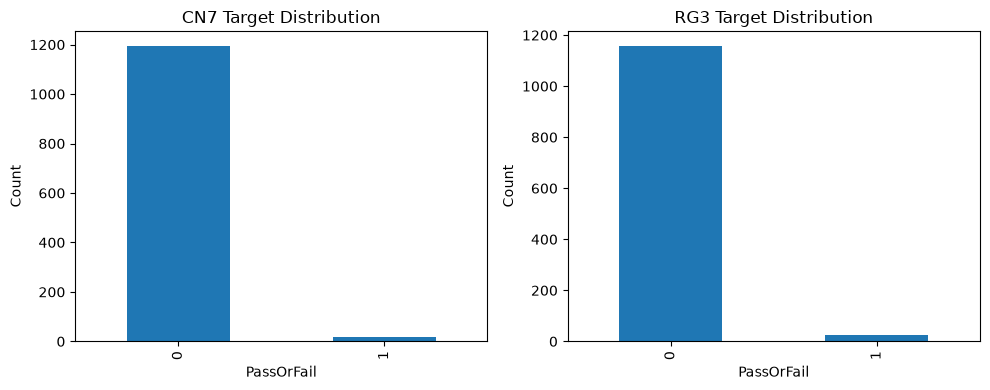

In [35]:
# Target 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, df) in zip(axes, DATASETS.items()):
    df[TARGET].value_counts().sort_index().plot(kind="bar", ax=ax)
    ax.set_title(f"{name} Target Distribution")
    ax.set_xlabel(TARGET)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


### 11) 왜도 확인

- 분포의 비대칭 정도를 확인합니다.


In [36]:
# Target 왜도 확인
# 불량 클래스가 매우 적으면 큰 양의 왜도가 나타날 수 있음
for name, df in DATASETS.items():
    print(f"[{name}] Target skewness:", round(df[TARGET].skew(), 4))


[CN7] Target skewness: 8.2716
[RG3] Target skewness: 6.6644


### 12) 극단값 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


---


# #4 수치형 변수 기초 통계

### 1) 평균

- 변수의 중심 수준을 비교합니다.


In [37]:
# 수치형 설명변수 평균 확인
for name, df in DATASETS.items():
    print(f"\n[{name}] 평균")
    display(df[FEATURE_COLS].mean().sort_values())



[CN7] 평균


Plasticizing_Position      -3.628403e-14
Barrel_Temperature_6       -3.579410e-14
Barrel_Temperature_2       -3.505481e-14
Injection_Time             -2.957172e-14
Barrel_Temperature_1       -1.824763e-14
Max_Switch_Over_Pressure   -1.592414e-14
Clamp_Close_Time           -1.574811e-14
Max_Screw_RPM              -6.688842e-15
Filling_Time               -5.351073e-15
Max_Back_Pressure          -3.755139e-15
Average_Back_Pressure      -3.708200e-15
Hopper_Temperature         -2.675537e-15
Mold_Temperature_3         -8.214367e-16
Mold_Temperature_4         -1.642873e-16
Clamp_Open_Position         0.000000e+00
Max_Injection_Speed         3.238808e-15
Barrel_Temperature_5        5.257195e-15
Plasticizing_Time           6.477615e-15
Barrel_Temperature_3        8.745367e-15
Barrel_Temperature_4        2.114319e-14
Average_Screw_RPM           4.196368e-14
Cycle_Time                  5.069438e-14
Max_Injection_Pressure      1.074909e-13
Cushion_Position            4.630532e-12
dtype: float64


[RG3] 평균


Average_Screw_RPM          -8.432736e-14
Barrel_Temperature_5       -7.989698e-14
Max_Injection_Pressure     -7.252105e-14
Injection_Time             -4.715311e-14
Barrel_Temperature_1       -4.462308e-14
Max_Injection_Speed        -2.755607e-14
Barrel_Temperature_6       -2.174910e-14
Plasticizing_Time          -1.760126e-14
Max_Screw_RPM              -1.206931e-14
Max_Switch_Over_Pressure   -1.161395e-14
Hopper_Temperature         -6.396087e-15
Mold_Temperature_3         -3.847270e-16
Filling_Time               -1.923635e-16
Clamp_Open_Position         0.000000e+00
Mold_Temperature_4          4.809088e-17
Max_Back_Pressure           6.588450e-15
Average_Back_Pressure       8.127359e-15
Barrel_Temperature_3        2.130276e-14
Barrel_Temperature_4        4.068789e-14
Barrel_Temperature_2        4.473654e-14
Clamp_Close_Time            4.972597e-14
Cycle_Time                  5.502649e-14
Plasticizing_Position       1.813267e-13
Cushion_Position            2.788886e-12
dtype: float64

### 2) 중앙값

- 이상치에 덜 민감한 중심값을 확인합니다.


In [38]:
# 수치형 설명변수 중앙값 확인
for name, df in DATASETS.items():
    print(f"\n[{name}] 중앙값")
    display(df[FEATURE_COLS].median().sort_values())



[CN7] 중앙값


Clamp_Close_Time           -0.902466
Cushion_Position           -0.711164
Plasticizing_Position      -0.642290
Injection_Time             -0.327014
Hopper_Temperature         -0.168996
Mold_Temperature_4         -0.155625
Average_Screw_RPM          -0.132022
Filling_Time               -0.120461
Barrel_Temperature_3       -0.037728
Plasticizing_Time          -0.036274
Max_Switch_Over_Pressure   -0.010481
Barrel_Temperature_4       -0.006117
Clamp_Open_Position         0.000000
Barrel_Temperature_5        0.008133
Barrel_Temperature_6        0.013158
Max_Injection_Speed         0.015756
Max_Screw_RPM               0.049553
Barrel_Temperature_1        0.056153
Barrel_Temperature_2        0.067358
Mold_Temperature_3          0.093154
Average_Back_Pressure       0.228490
Max_Back_Pressure           0.314806
Cycle_Time                  0.361047
Max_Injection_Pressure      0.635210
dtype: float64


[RG3] 중앙값


Max_Screw_RPM              -0.665752
Average_Screw_RPM          -0.421798
Clamp_Close_Time           -0.386790
Cushion_Position           -0.317055
Plasticizing_Position      -0.192928
Max_Injection_Speed        -0.167384
Max_Injection_Pressure     -0.108802
Max_Back_Pressure          -0.085805
Plasticizing_Time          -0.042538
Barrel_Temperature_5       -0.030765
Injection_Time             -0.029099
Barrel_Temperature_2       -0.011452
Barrel_Temperature_3       -0.002081
Clamp_Open_Position         0.000000
Mold_Temperature_4          0.002053
Barrel_Temperature_4        0.047749
Max_Switch_Over_Pressure    0.075729
Hopper_Temperature          0.081547
Average_Back_Pressure       0.088125
Barrel_Temperature_1        0.096629
Barrel_Temperature_6        0.143005
Mold_Temperature_3          0.173825
Cycle_Time                  0.249511
Filling_Time                0.838552
dtype: float64

### 3) 표준편차

- 변수의 변동성을 확인합니다.


In [39]:
# 수치형 설명변수 표준편차 확인
for name, df in DATASETS.items():
    print(f"\n[{name}] 표준편차")
    display(df[FEATURE_COLS].std().sort_values())



[CN7] 표준편차


Clamp_Open_Position         0.000000
Mold_Temperature_4          1.000413
Cycle_Time                  1.000413
Injection_Time              1.000413
Cushion_Position            1.000413
Clamp_Close_Time            1.000413
Plasticizing_Position       1.000413
Filling_Time                1.000413
Barrel_Temperature_1        1.000413
Max_Screw_RPM               1.000413
Average_Screw_RPM           1.000413
Max_Switch_Over_Pressure    1.000413
Average_Back_Pressure       1.000413
Barrel_Temperature_4        1.000413
Barrel_Temperature_2        1.000413
Max_Injection_Speed         1.000413
Barrel_Temperature_5        1.000413
Hopper_Temperature          1.000413
Mold_Temperature_3          1.000413
Barrel_Temperature_3        1.000413
Max_Back_Pressure           1.000413
Max_Injection_Pressure      1.000413
Plasticizing_Time           1.000413
Barrel_Temperature_6        1.000413
dtype: float64


[RG3] 표준편차


Clamp_Open_Position         0.000000
Injection_Time              1.000423
Plasticizing_Time           1.000423
Filling_Time                1.000423
Cycle_Time                  1.000423
Clamp_Close_Time            1.000423
Cushion_Position            1.000423
Plasticizing_Position       1.000423
Max_Injection_Speed         1.000423
Average_Screw_RPM           1.000423
Max_Back_Pressure           1.000423
Max_Switch_Over_Pressure    1.000423
Average_Back_Pressure       1.000423
Barrel_Temperature_1        1.000423
Barrel_Temperature_3        1.000423
Barrel_Temperature_2        1.000423
Barrel_Temperature_6        1.000423
Mold_Temperature_3          1.000423
Barrel_Temperature_4        1.000423
Barrel_Temperature_5        1.000423
Mold_Temperature_4          1.000423
Max_Injection_Pressure      1.000423
Max_Screw_RPM               1.000423
Hopper_Temperature          1.000423
dtype: float64

### 4) 최소값 / 최대값

- 변수의 값 범위를 확인합니다.


In [40]:
# 수치형 설명변수 최소/최대값 확인
for name, df in DATASETS.items():
    summary = pd.DataFrame({
        "min": df[FEATURE_COLS].min(),
        "max": df[FEATURE_COLS].max()
    })
    print(f"\n[{name}]")
    display(summary)



[CN7]


,min,max
Injection_Time,-7.549091,2.080358
Filling_Time,-7.776799,2.297327
Plasticizing_Time,-0.723425,20.038456
Cycle_Time,-3.706092,12.562466
Clamp_Close_Time,-0.902466,2.859537
Cushion_Position,-2.613163,6.943503
Plasticizing_Position,-2.876962,1.592429
Clamp_Open_Position,0.000000,0.000000
Max_Injection_Speed,-1.541785,9.555703
Max_Screw_RPM,-2.486330,3.430752



[RG3]


,min,max
Injection_Time,-8.627730,8.569634
Filling_Time,-1.192531,0.838552
Plasticizing_Time,-2.736231,3.773533
Cycle_Time,-1.395040,11.761888
Clamp_Close_Time,-1.806725,1.033078
Cushion_Position,-1.911818,2.867608
Plasticizing_Position,-2.537409,2.932550
Clamp_Open_Position,0.000000,0.000000
Max_Injection_Speed,-2.522291,2.187583
Max_Screw_RPM,-2.008588,2.019970


### 5) 사분위수

- 분포의 중앙 구간과 IQR을 확인합니다.


In [41]:
# 1사분위수(Q1), 중앙값(Q2), 3사분위수(Q3) 확인
for name, df in DATASETS.items():
    q = df[FEATURE_COLS].quantile([0.25, 0.50, 0.75]).T
    q.columns = ["Q1", "Q2", "Q3"]
    print(f"\n[{name}]")
    display(q)



[CN7]


,Q1,Q2,Q3
Injection_Time,-0.728249,-0.327014,0.876653
Filling_Time,-0.523416,-0.120461,0.685468
Plasticizing_Time,-0.379849,-0.036274,0.209135
Cycle_Time,-0.655762,0.361047,0.361047
Clamp_Close_Time,-0.902466,-0.902466,0.978580
Cushion_Position,-0.711164,-0.711164,1.202502
Plasticizing_Position,-0.702654,-0.642290,1.471608
Clamp_Open_Position,0.000000,0.000000,0.000000
Max_Injection_Speed,-0.568321,0.015756,0.405143
Max_Screw_RPM,-0.795730,0.049553,0.894853



[RG3]


,Q1,Q2,Q3
Injection_Time,-0.029099,-0.029099,-0.029099
Filling_Time,-1.192531,0.838552,0.838552
Plasticizing_Time,-0.715956,-0.042538,0.630880
Cycle_Time,-0.298708,0.249511,0.249511
Clamp_Close_Time,-0.386790,-0.386790,1.033078
Cushion_Position,-1.114437,-0.317055,0.480326
Plasticizing_Position,-0.974521,-0.192928,0.588367
Clamp_Open_Position,0.000000,0.000000,0.000000
Max_Injection_Speed,-0.952293,-0.167384,0.617645
Max_Screw_RPM,-0.665752,-0.665752,0.677109


### 6) 왜도

- 분포의 비대칭 정도를 확인합니다.


In [42]:
# 왜도 확인: 절대값이 클수록 한쪽으로 치우친 분포
for name, df in DATASETS.items():
    print(f"\n[{name}] 왜도")
    display(df[FEATURE_COLS].skew().abs().sort_values(ascending=False).to_frame("|skew|"))



[CN7] 왜도


,|skew|
Plasticizing_Time,15.166877
Average_Screw_RPM,8.987925
Max_Injection_Speed,5.271690
Cycle_Time,4.769294
Max_Injection_Pressure,2.879362
Max_Switch_Over_Pressure,2.219345
Cushion_Position,1.015655
Average_Back_Pressure,0.897403
Filling_Time,0.896455
Injection_Time,0.808191



[RG3] 왜도


,|skew|
Cycle_Time,8.386585
Max_Switch_Over_Pressure,8.270600
Injection_Time,2.066939
Hopper_Temperature,0.596808
Plasticizing_Time,0.546343
Clamp_Close_Time,0.439056
Barrel_Temperature_5,0.431009
Filling_Time,0.354429
Barrel_Temperature_2,0.289997
Max_Injection_Pressure,0.275562


### 7) 첨도

- 분포 꼬리와 극단값 경향을 확인합니다.


In [43]:
# 첨도 확인: 값이 클수록 꼬리가 두껍고 극단값이 많을 가능성
for name, df in DATASETS.items():
    print(f"\n[{name}] 첨도")
    display(df[FEATURE_COLS].kurt().sort_values(ascending=False).to_frame("kurtosis"))



[CN7] 첨도


,kurtosis
Plasticizing_Time,281.585669
Average_Screw_RPM,128.886746
Cycle_Time,56.230174
Max_Injection_Speed,46.999535
Max_Injection_Pressure,24.025147
Max_Switch_Over_Pressure,20.100283
Filling_Time,6.703002
Injection_Time,6.098331
Cushion_Position,2.465733
Average_Back_Pressure,2.248759



[RG3] 첨도


,kurtosis
Max_Switch_Over_Pressure,109.775127
Cycle_Time,96.645025
Injection_Time,71.060110
Barrel_Temperature_5,1.644662
Plasticizing_Time,0.457142
Hopper_Temperature,0.102952
Average_Screw_RPM,0.094839
Clamp_Open_Position,0.000000
Barrel_Temperature_3,-0.100903
Barrel_Temperature_1,-0.191491


### 8) 0 또는 특정 값에 데이터가 몰려있는지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [44]:
# 0이 차지하는 비율과 최빈값 비율 확인
for name, df in DATASETS.items():
    result = []
    for col in FEATURE_COLS:
        zero_ratio = (df[col] == 0).mean() * 100
        top_ratio = df[col].value_counts(normalize=True, dropna=False).iloc[0] * 100
        result.append([col, zero_ratio, top_ratio])

    result = pd.DataFrame(result, columns=["column", "zero_ratio(%)", "top_value_ratio(%)"])
    print(f"\n[{name}]")
    display(result.sort_values("top_value_ratio(%)", ascending=False))



[CN7]


,column,zero_ratio(%),top_value_ratio(%)
7,Clamp_Open_Position,100.0,100.000000
10,Average_Screw_RPM,0.0,74.566474
5,Cushion_Position,0.0,62.840628
4,Clamp_Close_Time,0.0,53.674649
3,Cycle_Time,0.0,53.592073
11,Max_Injection_Pressure,0.0,47.646573
9,Max_Screw_RPM,0.0,34.516928
6,Plasticizing_Position,0.0,29.397192
17,Barrel_Temperature_3,0.0,21.800165
20,Barrel_Temperature_6,0.0,20.478943



[RG3]


,column,zero_ratio(%),top_value_ratio(%)
7,Clamp_Open_Position,100.0,100.000000
0,Injection_Time,0.0,98.646362
3,Cycle_Time,0.0,62.774958
1,Filling_Time,0.0,58.714044
10,Average_Screw_RPM,0.0,58.375635
4,Clamp_Close_Time,0.0,42.978003
9,Max_Screw_RPM,0.0,42.808799
6,Plasticizing_Position,0.0,30.287648
5,Cushion_Position,0.0,28.257191
8,Max_Injection_Speed,0.0,27.072758


---


# #5 수치형 변수 분포 분석

### 1) Histogram

- 변수별 전체 분포 형태를 시각적으로 확인합니다.


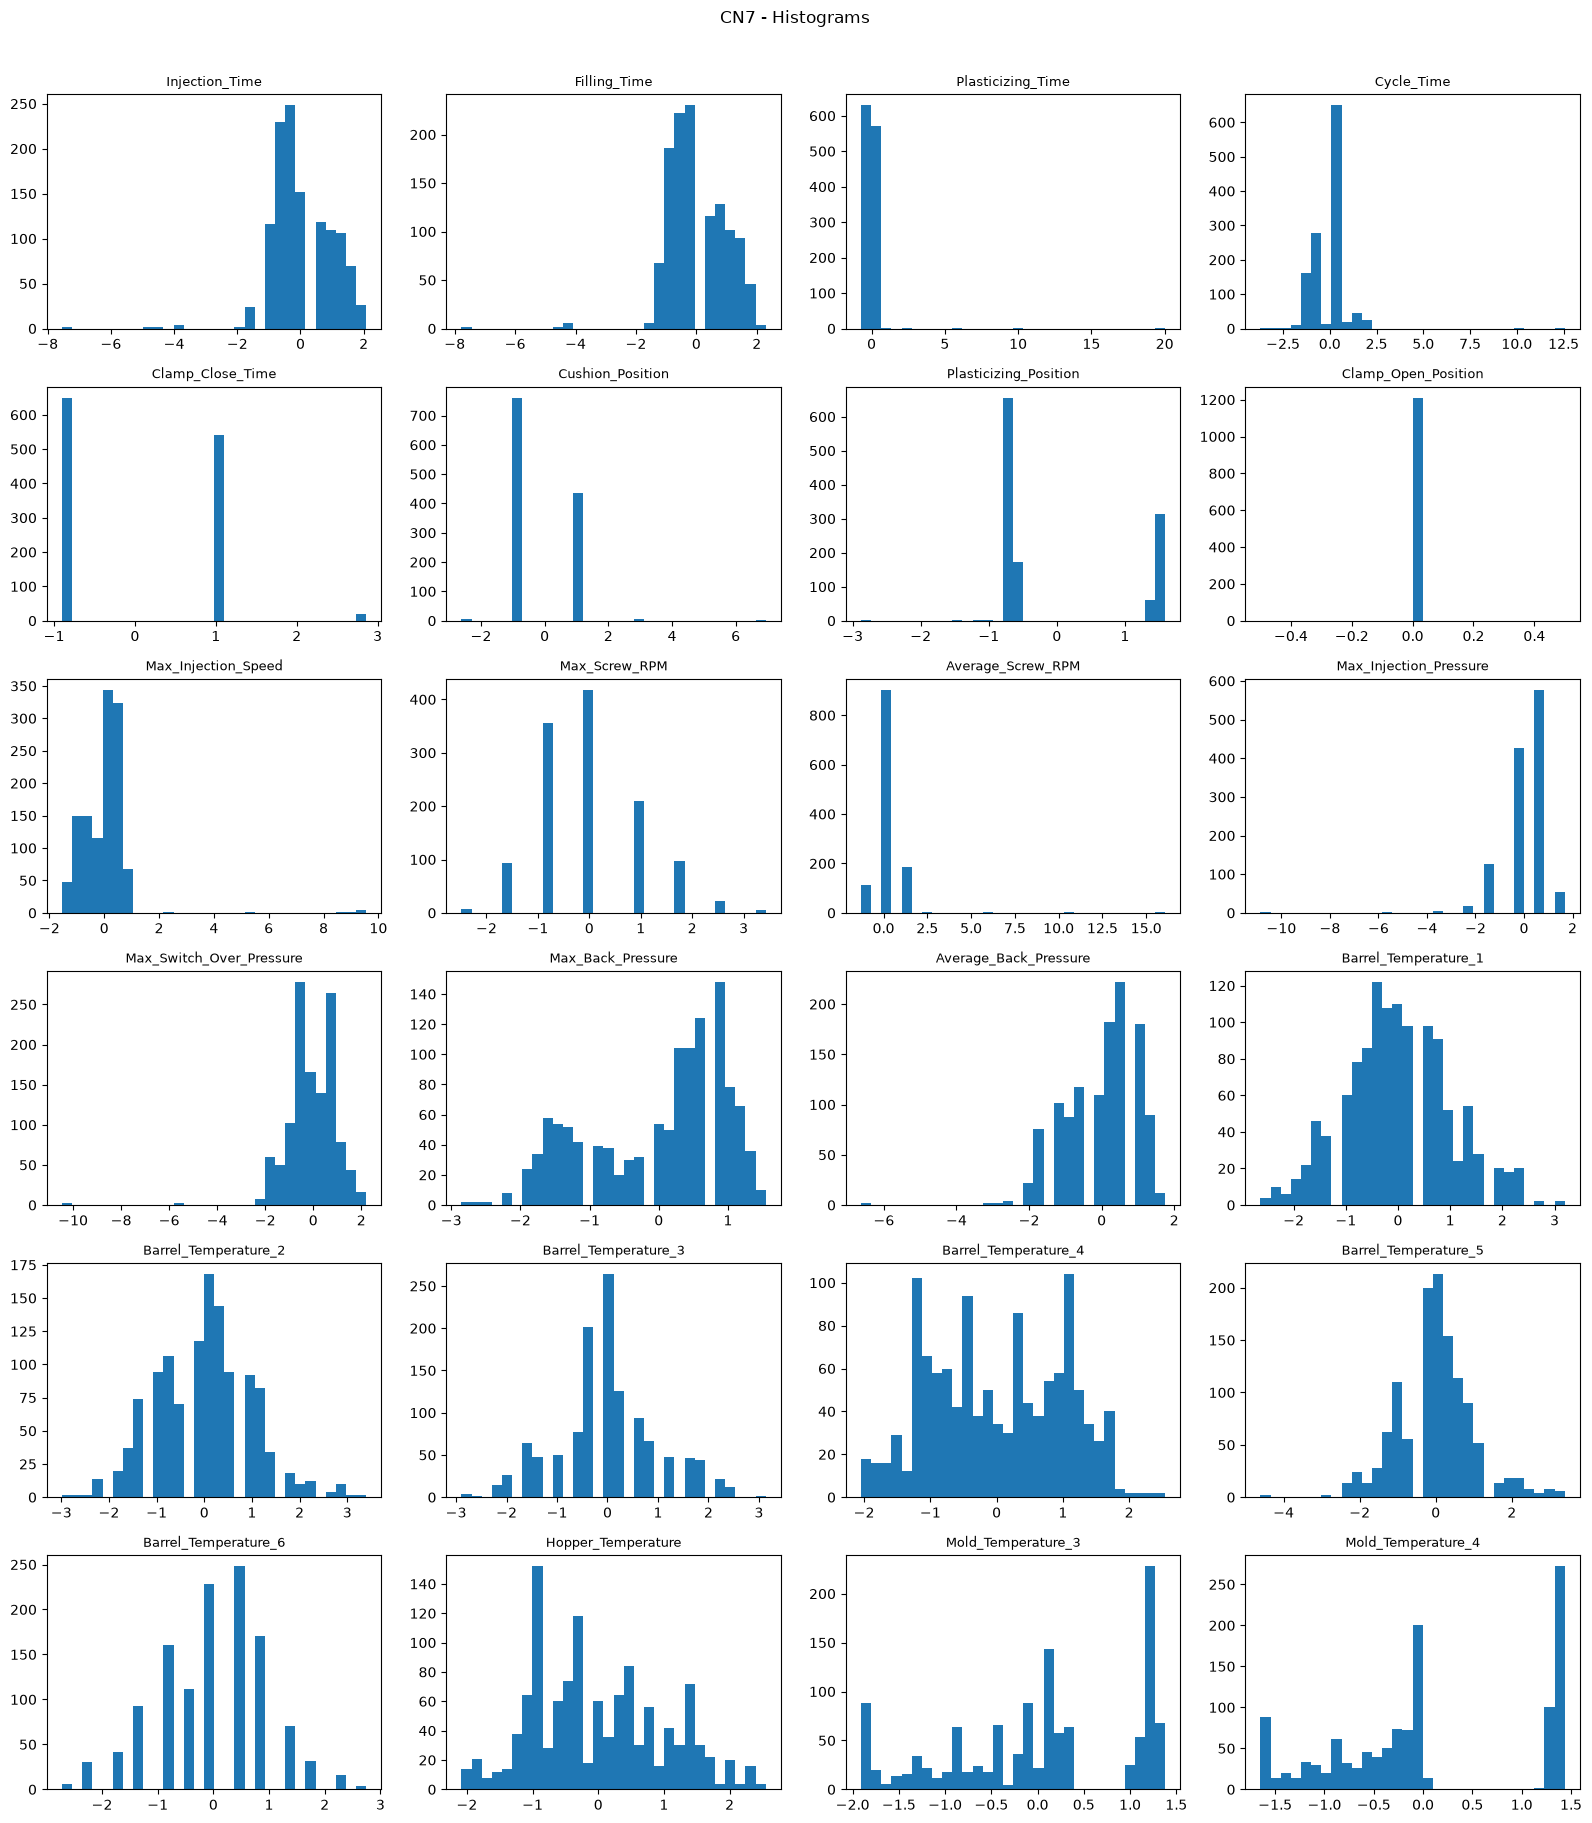

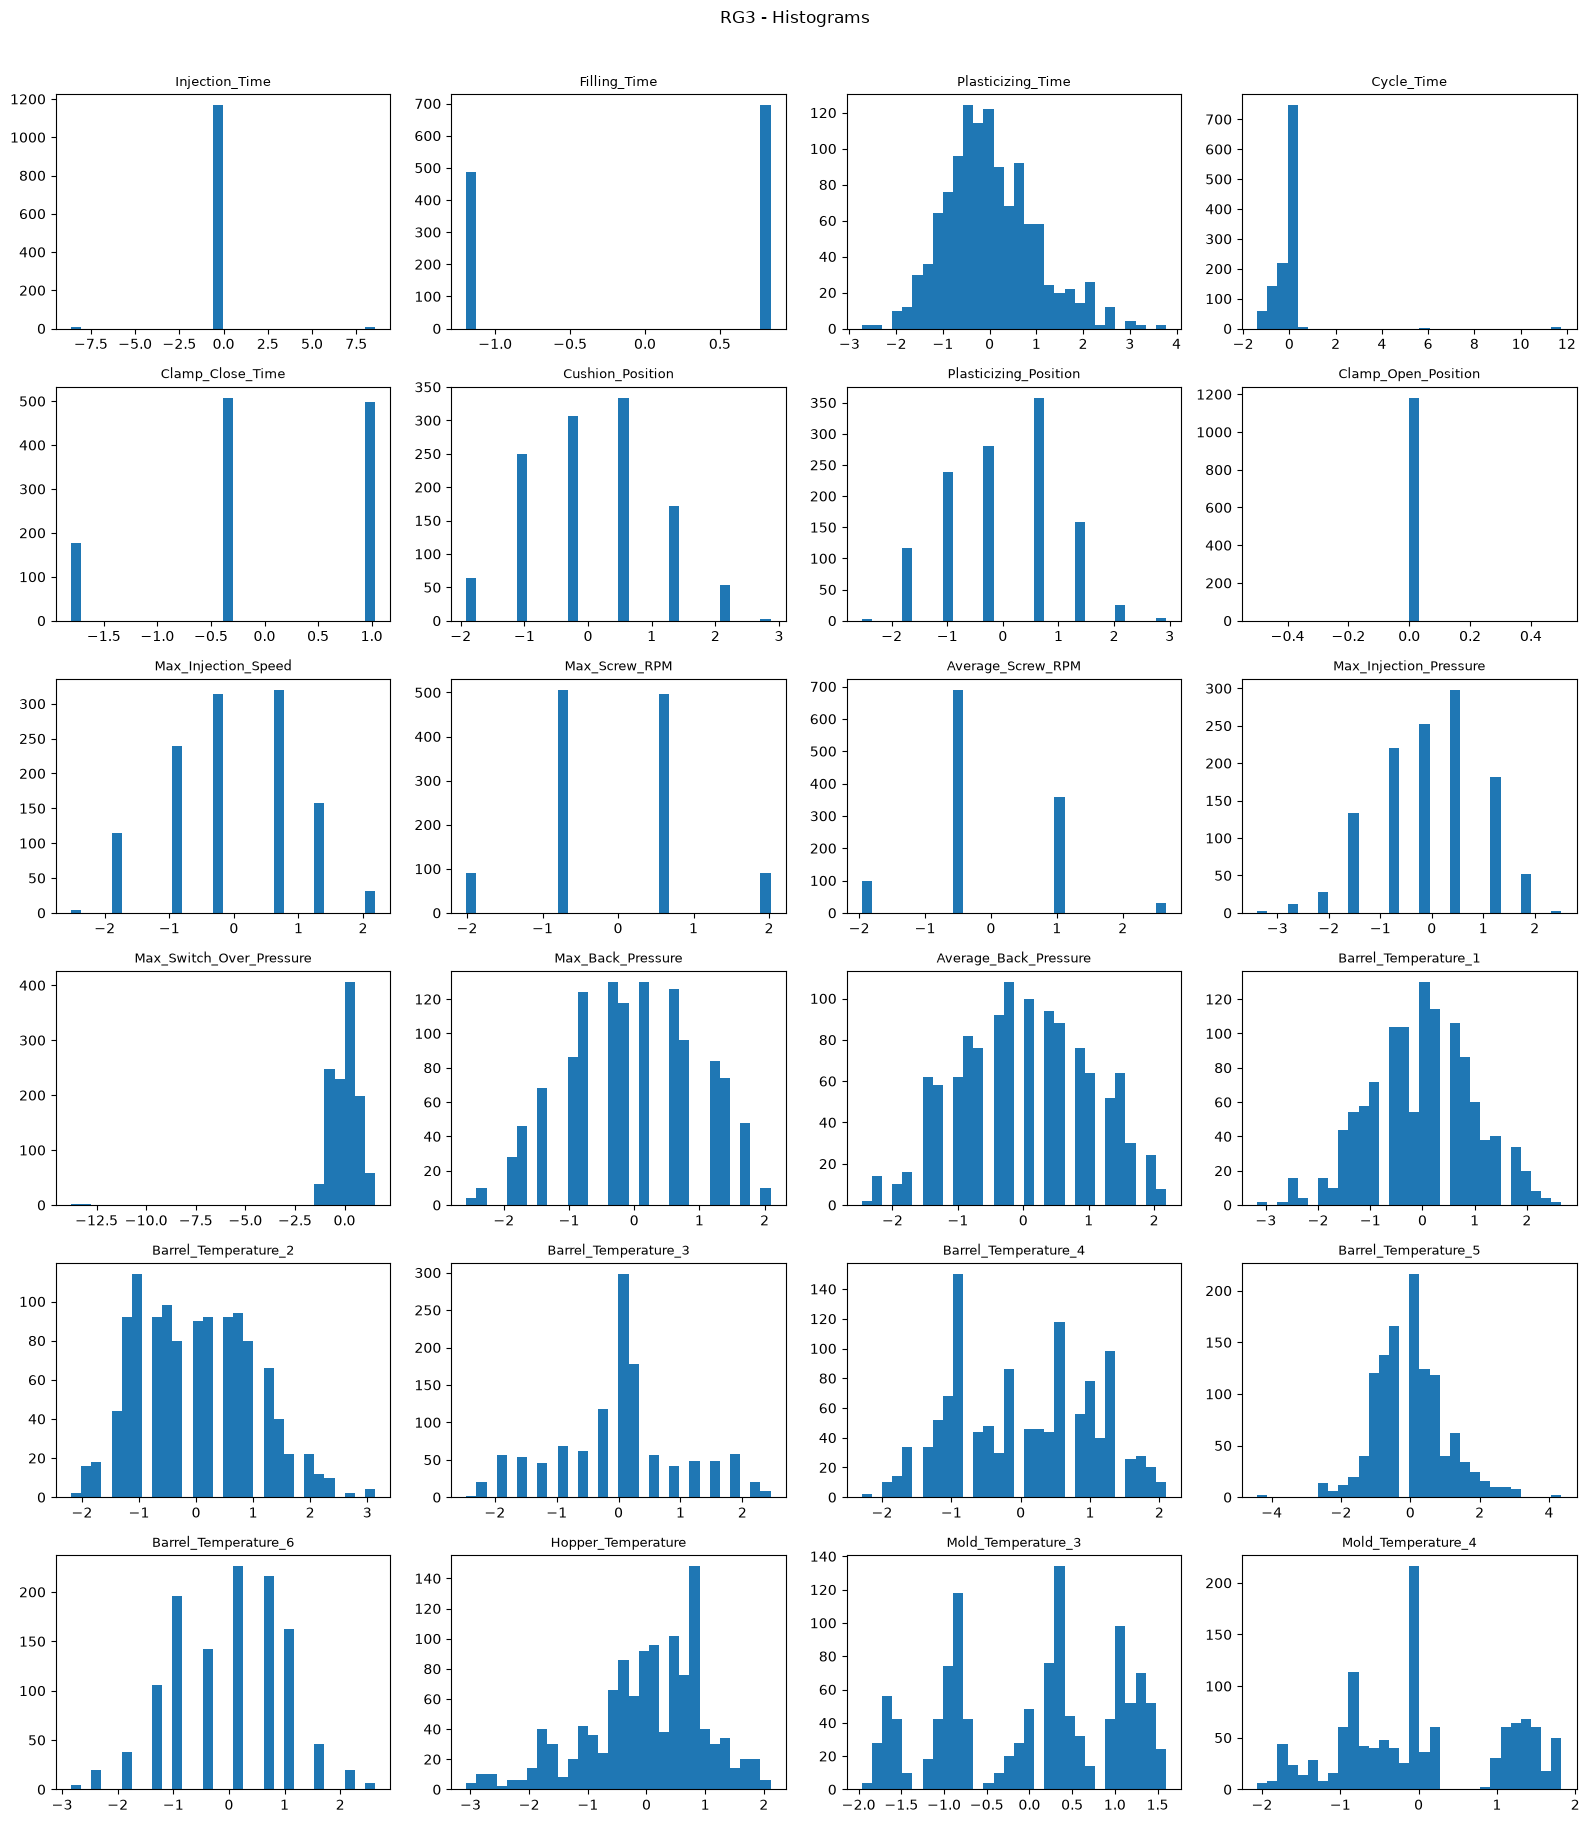

In [45]:
# 각 수치형 변수의 Histogram 확인
for name, df in DATASETS.items():
    cols = FEATURE_COLS
    ncols = 4
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, cols):
        ax.hist(df[col].dropna(), bins=30)
        ax.set_title(col, fontsize=9)

    for ax in axes[len(cols):]:
        ax.axis("off")

    fig.suptitle(f"{name} - Histograms", y=1.01)
    plt.tight_layout()
    plt.show()


### 2) KDE Plot

- 연속형 변수의 밀도 형태를 확인합니다.


C:\Users\Administrator\AppData\Local\Temp\ipykernel_40508\1392987856.py:17: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_40508\1392987856.py:17: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_40508\1392987856.py:17: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_40508\1392987856.py:17: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Administrator\Desktop\kamp\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Administrator\Desktop\kamp\.venv\Lib\site-pac

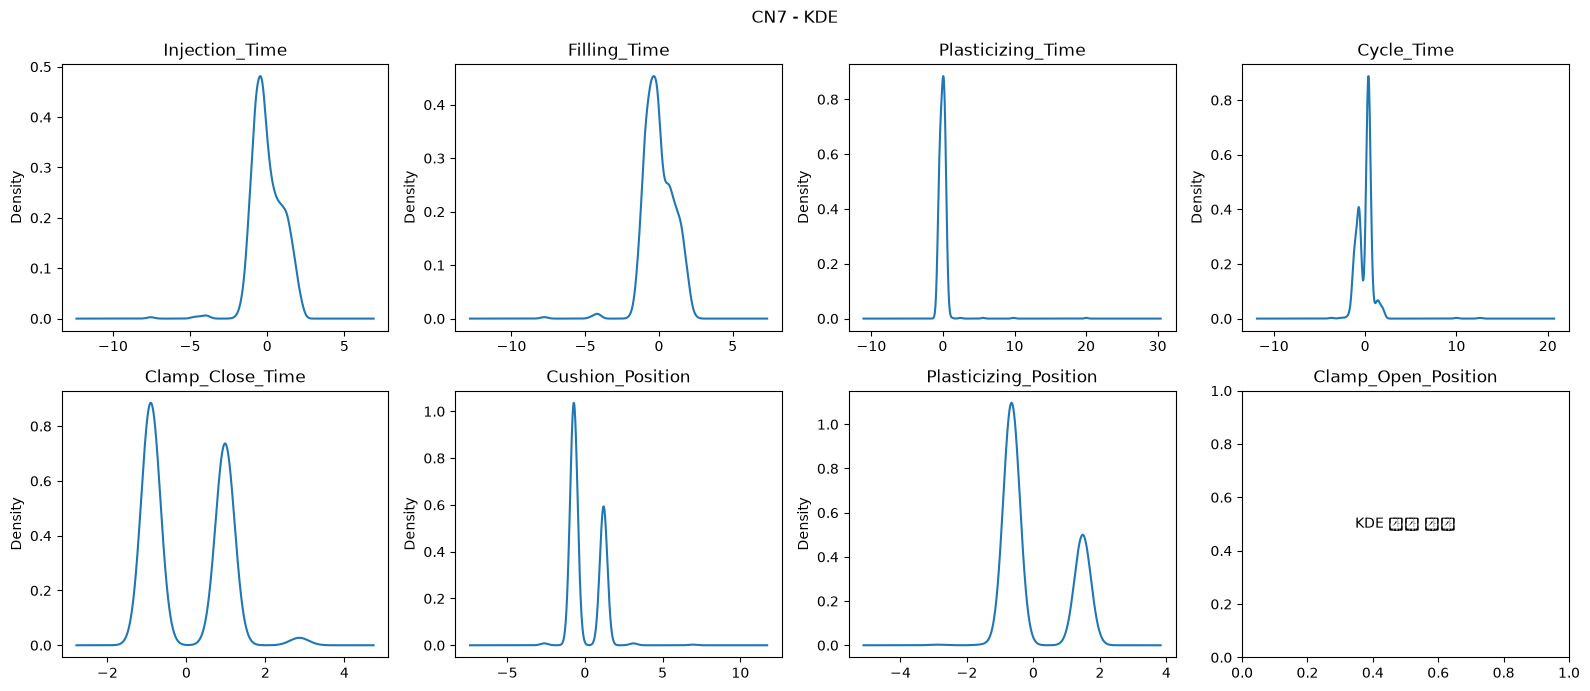

C:\Users\Administrator\AppData\Local\Temp\ipykernel_40508\1392987856.py:17: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_40508\1392987856.py:17: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_40508\1392987856.py:17: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_40508\1392987856.py:17: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Administrator\Desktop\kamp\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Administrator\Desktop\kamp\.venv\Lib\site-pac

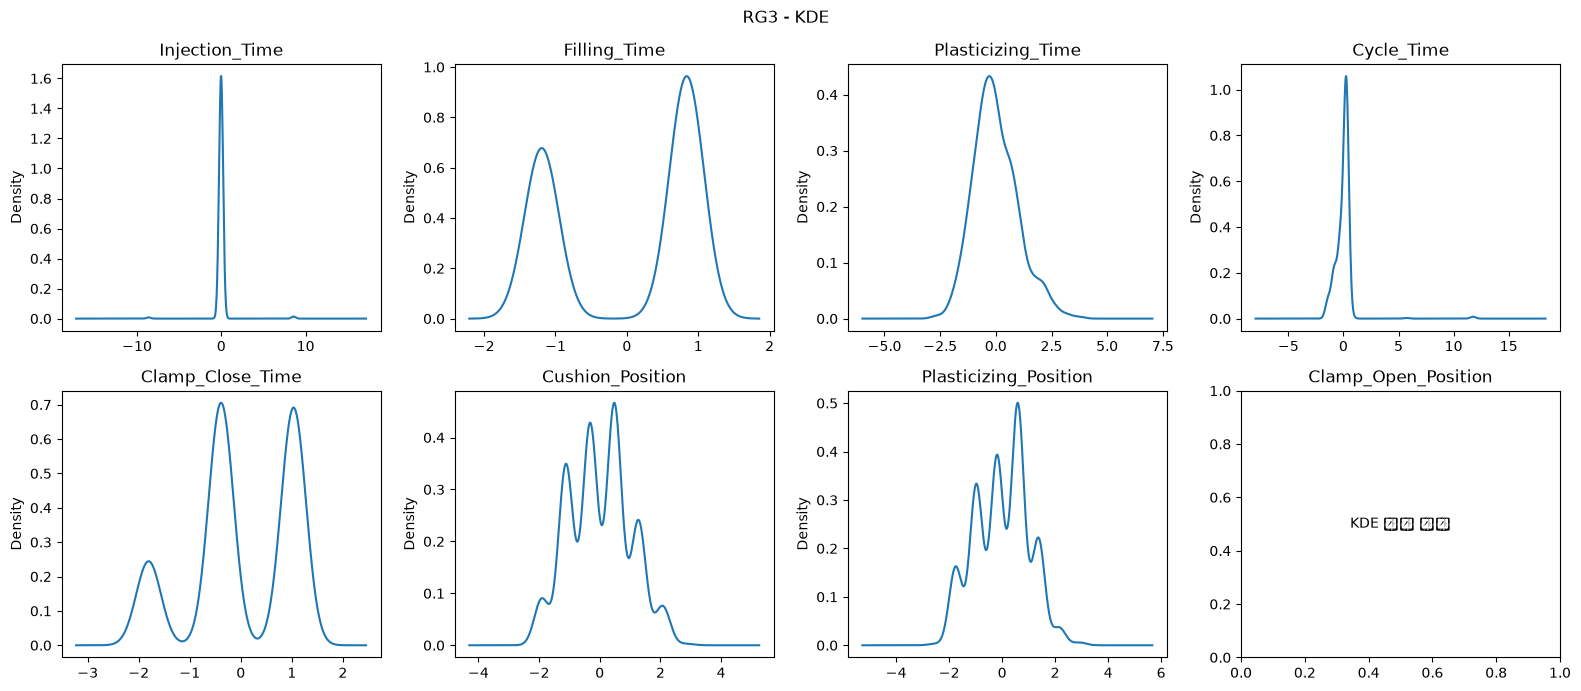

In [46]:
# KDE(밀도) 분포 확인
# 환경에 scipy가 없다면 해당 컬럼은 건너뜀
for name, df in DATASETS.items():
    cols = FEATURE_COLS[:8]  # 너무 많은 그래프를 피하기 위해 앞 8개 우선 확인
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes = axes.reshape(-1)

    for ax, col in zip(axes, cols):
        try:
            df[col].dropna().plot(kind="kde", ax=ax)
            ax.set_title(col)
        except Exception:
            ax.text(0.5, 0.5, "KDE 계산 불가", ha="center", va="center")
            ax.set_title(col)

    fig.suptitle(f"{name} - KDE")
    plt.tight_layout()
    plt.show()


### 3) Boxplot

- 중앙값, IQR, 이상치 후보를 한눈에 확인합니다.


C:\Users\Administrator\AppData\Local\Temp\ipykernel_40508\2911639306.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


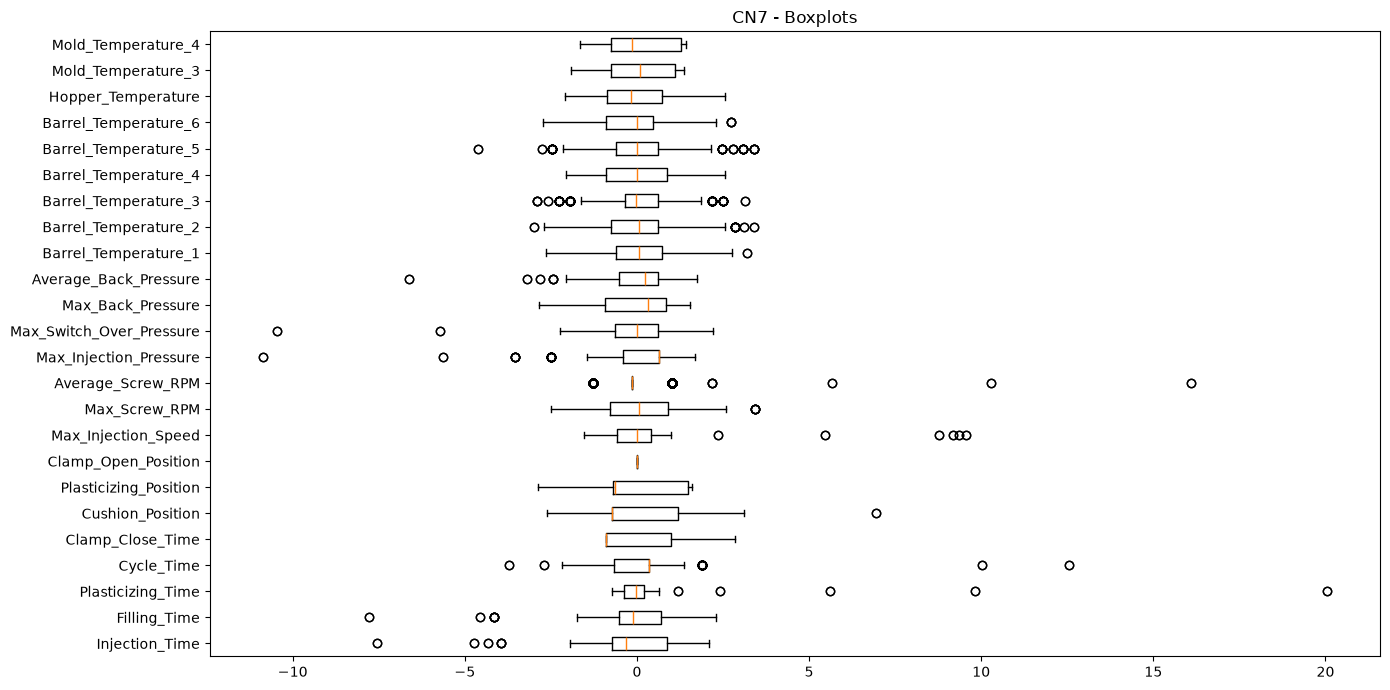

C:\Users\Administrator\AppData\Local\Temp\ipykernel_40508\2911639306.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


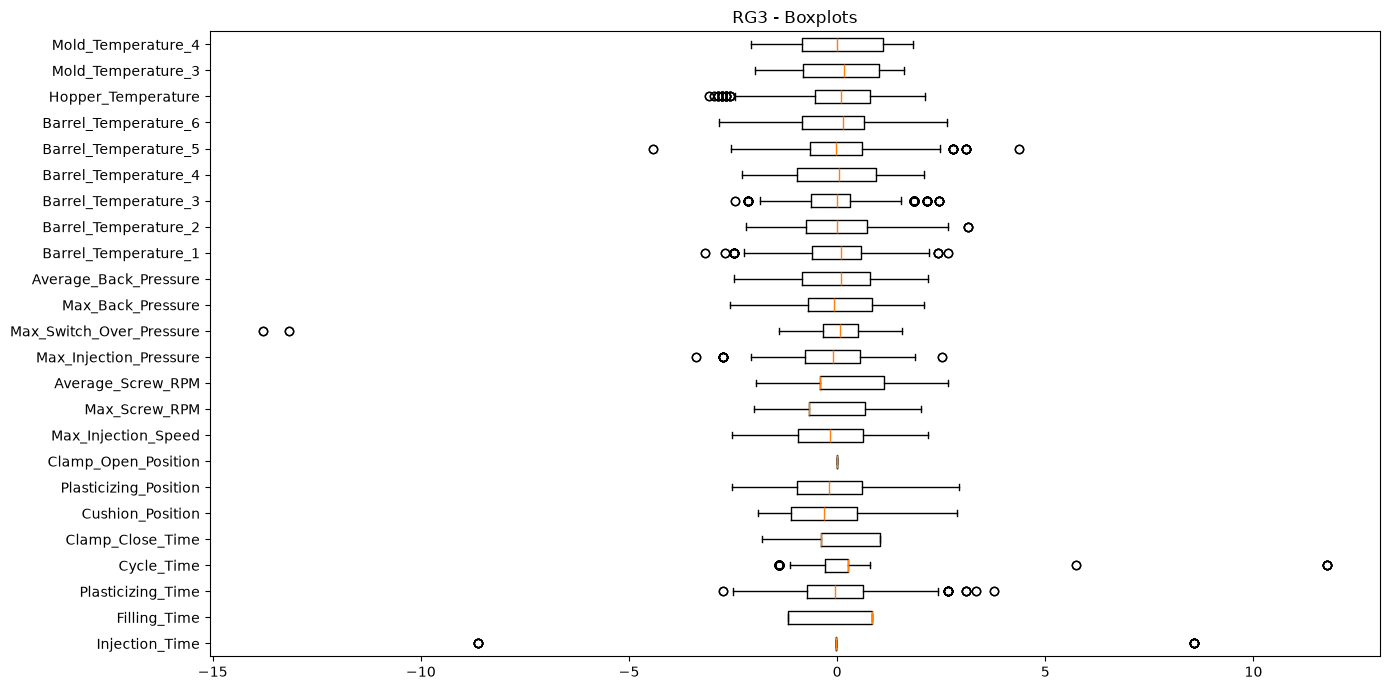

In [48]:
# 각 수치형 변수의 Boxplot 확인
for name, df in DATASETS.items():
    fig, ax = plt.subplots(figsize=(14, 7))

    ax.boxplot(
        [df[c].dropna() for c in FEATURE_COLS],
        tick_labels=FEATURE_COLS,
        vert=False
    )

    ax.set_title(f"{name} - Boxplots")
    plt.tight_layout()
    plt.show()

### 4) 분포의 치우침 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 절대 왜도가 큰 변수부터 확인
for name, df in DATASETS.items():
    skewness = df[FEATURE_COLS].skew().sort_values(key=np.abs, ascending=False)
    print(f"\n[{name}] 치우침이 큰 변수")
    display(skewness.to_frame("skewness"))


### 5) 극단값 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 변수별 상위 1%, 하위 1% 경계값 확인
for name, df in DATASETS.items():
    extreme = pd.DataFrame({
        "1%": df[FEATURE_COLS].quantile(0.01),
        "99%": df[FEATURE_COLS].quantile(0.99),
        "min": df[FEATURE_COLS].min(),
        "max": df[FEATURE_COLS].max()
    })

    print(f"\n[{name}]")
    display(extreme)


### 6) 이상치 후보 탐색

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# IQR 기준 이상치 후보 개수 확인
for name, df in DATASETS.items():
    q1 = df[FEATURE_COLS].quantile(0.25)
    q3 = df[FEATURE_COLS].quantile(0.75)
    iqr = q3 - q1

    outlier_mask = (df[FEATURE_COLS] < (q1 - 1.5 * iqr)) | (df[FEATURE_COLS] > (q3 + 1.5 * iqr))
    outlier_count = outlier_mask.sum().sort_values(ascending=False)

    print(f"\n[{name}]")
    display(outlier_count.to_frame("IQR_outlier_count"))


### 7) 로그 변환이 필요한 변수 확인

- 강하게 치우친 양수 변수의 변환 필요성을 점검합니다.


In [ ]:
# 로그 변환 후보 확인
# 일반적으로 양수값만 가지며 왜도가 큰 변수(|skew| > 1)를 후보로 봄
for name, df in DATASETS.items():
    candidates = []
    for col in FEATURE_COLS:
        if (df[col].dropna() > 0).all() and abs(df[col].skew()) > 1:
            candidates.append((col, df[col].skew()))

    print(f"[{name}] 로그 변환 후보:", candidates)
    print("※ 현재 데이터가 이미 표준화된 값이라면 로그 변환은 적용하지 않는 것이 적절합니다.")


### 8) 변수별 스케일 차이 확인

- 변수 간 값의 크기 차이를 확인합니다.


In [ ]:
# 변수별 표준편차를 비교하여 스케일 차이 확인
for name, df in DATASETS.items():
    scale = pd.DataFrame({
        "mean": df[FEATURE_COLS].mean(),
        "std": df[FEATURE_COLS].std(),
        "min": df[FEATURE_COLS].min(),
        "max": df[FEATURE_COLS].max()
    }).sort_values("std", ascending=False)

    print(f"\n[{name}]")
    display(scale)


---


# #6 범주형 변수 분석

### 1) 카테고리 종류 수

- 범주형 변수가 존재할 경우 분포와 희소 범주를 확인합니다.


In [ ]:
# 범주형 변수별 카테고리 종류 수 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    print(f"[{name}] 범주형 변수:", cat_cols)
    if cat_cols:
        display(df[cat_cols].nunique().to_frame("n_categories"))


### 2) 카테고리별 빈도수

- 범주형 변수가 존재할 경우 분포와 희소 범주를 확인합니다.


In [ ]:
# 범주형 변수별 빈도수 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    print(f"\n[{name}]")
    if not cat_cols:
        print("범주형 설명변수가 없습니다.")
    for col in cat_cols:
        print(f"\n{col}")
        display(df[col].value_counts(dropna=False))


### 3) 카테고리별 비율

- 범주형 변수가 존재할 경우 분포와 희소 범주를 확인합니다.


In [ ]:
# 범주형 변수별 비율 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    print(f"\n[{name}]")
    if not cat_cols:
        print("범주형 설명변수가 없습니다.")
    for col in cat_cols:
        display((df[col].value_counts(normalize=True, dropna=False) * 100).to_frame("ratio(%)"))


### 4) 고유값이 지나치게 많은 변수 확인

- 변수별 값의 다양성과 ID성 여부를 확인합니다.


In [ ]:
# 고유값이 지나치게 많은 범주형 변수 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    high_cardinality = [(c, df[c].nunique()) for c in cat_cols if df[c].nunique() > 20]
    print(f"[{name}] 고카디널리티 범주형 변수:", high_cardinality)


### 5) 희소한 범주 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 전체의 1% 미만인 희소 범주 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    print(f"\n[{name}]")
    for col in cat_cols:
        ratio = df[col].value_counts(normalize=True, dropna=False)
        rare = ratio[ratio < 0.01]
        if len(rare):
            print(col)
            display((rare * 100).to_frame("ratio(%)"))
    if not cat_cols:
        print("범주형 설명변수가 없습니다.")


### 6) 거의 한 범주만 존재하는 변수 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 한 범주가 95% 이상을 차지하는 변수 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    dominated = []
    for col in cat_cols:
        top_ratio = df[col].value_counts(normalize=True, dropna=False).iloc[0]
        if top_ratio >= 0.95:
            dominated.append((col, round(top_ratio * 100, 2)))
    print(f"[{name}] 거의 한 범주만 존재:", dominated)


### 7) 오타 / 표기 방식 차이 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 문자열의 공백/대소문자 차이로 생긴 표기 불일치 후보 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(include="object").columns.tolist()
    print(f"\n[{name}]")
    if not cat_cols:
        print("문자열 범주형 변수가 없습니다.")
    for col in cat_cols:
        raw_n = df[col].nunique(dropna=False)
        normalized_n = df[col].astype(str).str.strip().str.lower().nunique(dropna=False)
        print(col, "| 원본:", raw_n, "| 정규화 후:", normalized_n)


### 8) 통합 가능한 범주 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 정규화 후 동일해지는 범주가 있는지 확인하여 통합 가능 후보 탐색
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(include="object").columns.tolist()
    print(f"\n[{name}]")
    for col in cat_cols:
        temp = pd.DataFrame({
            "raw": df[col].astype(str),
            "normalized": df[col].astype(str).str.strip().str.lower()
        })
        merged = temp.groupby("normalized")["raw"].nunique()
        print(col, "통합 후보 개수:", (merged > 1).sum())
    if not cat_cols:
        print("통합을 검토할 문자열 범주형 변수가 없습니다.")


---


# #7 날짜 / 시간 변수 분석

### 1) 데이터 수집 기간 확인

- 실제 날짜형 변수가 있을 경우 관측 기간을 확인합니다.


In [ ]:
# 실제 날짜형 컬럼 기준 데이터 수집 기간 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 실제 날짜/타임스탬프 컬럼이 없습니다.")
    for col in date_cols:
        print(f"[{name}] {col} 기간:", df[col].max() - df[col].min())


### 2) 최초 날짜 / 최근 날짜 확인

- 관측 시작일과 종료일을 확인합니다.


In [ ]:
# 최초 날짜 / 최근 날짜 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 날짜형 컬럼 없음")
    for col in date_cols:
        print(f"[{name}] {col}:", df[col].min(), "~", df[col].max())


### 3) 연도별 분포

- 시간에 따른 연도 단위 분포를 확인합니다.


In [ ]:
# 연도별 데이터 수 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 날짜형 컬럼이 없어 연도별 분석을 생략합니다.")
    for col in date_cols:
        display(df[col].dt.year.value_counts().sort_index())


### 4) 월별 분포

- 월 단위 계절성/집중 여부를 확인합니다.


In [ ]:
# 월별 데이터 수 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 날짜형 컬럼이 없어 월별 분석을 생략합니다.")
    for col in date_cols:
        display(df[col].dt.month.value_counts().sort_index())


### 5) 요일별 분포

- 요일별 패턴 여부를 확인합니다.


In [ ]:
# 요일별 데이터 수 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 날짜형 컬럼이 없어 요일별 분석을 생략합니다.")
    for col in date_cols:
        display(df[col].dt.day_name().value_counts())


### 6) 시간대별 분포

- 시간대별 패턴 여부를 확인합니다.


In [ ]:
# 시간대별 데이터 수 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 날짜형 컬럼이 없어 시간대별 분석을 생략합니다.")
    for col in date_cols:
        display(df[col].dt.hour.value_counts().sort_index())


### 7) 기간별 데이터 수 변화 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 일 단위 생산/수집 데이터 수 변화 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 날짜형 컬럼이 없어 기간별 변화 분석을 생략합니다.")
    for col in date_cols:
        daily = df.set_index(col).resample("D").size()
        display(daily.to_frame("count"))


### 8) 특정 시점에 데이터가 집중되는지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 특정 날짜/시점에 데이터가 과도하게 집중되는지 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 날짜형 컬럼이 없어 시점 집중도 분석을 생략합니다.")
    for col in date_cols:
        day_ratio = df[col].dt.date.astype(str).value_counts(normalize=True).head(10) * 100
        display(day_ratio.to_frame("ratio(%)"))


### 9) 데이터가 없는 기간 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 날짜형 컬럼이 있는 경우 연속 일자에서 비어 있는 날짜 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 날짜형 컬럼이 없어 누락 기간 분석을 생략합니다.")
    for col in date_cols:
        observed = pd.DatetimeIndex(df[col].dt.normalize().dropna().unique())
        full = pd.date_range(observed.min(), observed.max(), freq="D")
        missing_days = full.difference(observed)
        print(f"[{name}] {col} 누락 날짜 수:", len(missing_days))


---


# #8 Target별 수치형 변수 비교

### 1) 클래스별 평균 비교

- 변수의 중심 수준을 비교합니다.


In [ ]:
# Target 클래스별 수치형 설명변수 평균 비교
for name, df in DATASETS.items():
    print(f"\n[{name}]")
    display(df.groupby(TARGET)[FEATURE_COLS].mean().T)


### 2) 클래스별 중앙값 비교

- 이상치에 덜 민감한 중심값을 확인합니다.


In [ ]:
# Target 클래스별 수치형 설명변수 중앙값 비교
for name, df in DATASETS.items():
    print(f"\n[{name}]")
    display(df.groupby(TARGET)[FEATURE_COLS].median().T)


### 3) 클래스별 표준편차 비교

- 변수의 변동성을 확인합니다.


In [ ]:
# Target 클래스별 수치형 설명변수 표준편차 비교
for name, df in DATASETS.items():
    print(f"\n[{name}]")
    display(df.groupby(TARGET)[FEATURE_COLS].std().T)


### 4) Boxplot 비교

- 중앙값, IQR, 이상치 후보를 한눈에 확인합니다.


In [ ]:
# 클래스 간 평균 차이가 큰 상위 6개 변수의 Boxplot
for name, df in DATASETS.items():
    means = df.groupby(TARGET)[FEATURE_COLS].mean()
    if means.shape[0] == 2:
        top_cols = (means.iloc[1] - means.iloc[0]).abs().sort_values(ascending=False).head(6).index

        fig, axes = plt.subplots(2, 3, figsize=(14, 8))
        for ax, col in zip(axes.reshape(-1), top_cols):
            data_by_class = [df.loc[df[TARGET] == cls, col].dropna() for cls in sorted(df[TARGET].unique())]
            ax.boxplot(data_by_class, labels=sorted(df[TARGET].unique()))
            ax.set_title(col)
            ax.set_xlabel(TARGET)

        fig.suptitle(f"{name} - Target별 Boxplot")
        plt.tight_layout()
        plt.show()


### 5) Histogram / KDE 비교

- 변수별 전체 분포 형태를 시각적으로 확인합니다.


In [ ]:
# Target별 분포 차이가 큰 상위 변수의 Histogram 비교
for name, df in DATASETS.items():
    means = df.groupby(TARGET)[FEATURE_COLS].mean()
    if means.shape[0] == 2:
        top_cols = (means.iloc[1] - means.iloc[0]).abs().sort_values(ascending=False).head(4).index

        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        for ax, col in zip(axes.reshape(-1), top_cols):
            for cls in sorted(df[TARGET].unique()):
                ax.hist(df.loc[df[TARGET] == cls, col].dropna(), bins=25, alpha=0.5, label=f"{TARGET}={cls}")
            ax.set_title(col)
            ax.legend()

        fig.suptitle(f"{name} - Target별 Histogram")
        plt.tight_layout()
        plt.show()


### 6) 두 그룹 간 분포 차이 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 두 Target 그룹 간 표준화 평균 차이(Standardized Mean Difference) 계산
for name, df in DATASETS.items():
    classes = sorted(df[TARGET].dropna().unique())
    if len(classes) == 2:
        c0, c1 = classes
        result = {}

        for col in FEATURE_COLS:
            x0 = df.loc[df[TARGET] == c0, col].dropna()
            x1 = df.loc[df[TARGET] == c1, col].dropna()
            pooled_std = np.sqrt((x0.var(ddof=1) + x1.var(ddof=1)) / 2)
            result[col] = np.nan if pooled_std == 0 else (x1.mean() - x0.mean()) / pooled_std

        smd = pd.Series(result, name="SMD").sort_values(key=np.abs, ascending=False)
        print(f"\n[{name}]")
        display(smd.to_frame())


### 7) Target별 차이가 큰 변수 탐색

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [ ]:
# Target별 차이가 큰 변수 순위 확인
for name, df in DATASETS.items():
    classes = sorted(df[TARGET].dropna().unique())
    if len(classes) == 2:
        c0, c1 = classes
        ranking = []

        for col in FEATURE_COLS:
            x0 = df.loc[df[TARGET] == c0, col]
            x1 = df.loc[df[TARGET] == c1, col]
            pooled_std = np.sqrt((x0.var() + x1.var()) / 2)
            smd = np.nan if pooled_std == 0 else (x1.mean() - x0.mean()) / pooled_std
            ranking.append([col, x0.mean(), x1.mean(), smd, abs(smd) if pd.notna(smd) else np.nan])

        ranking = pd.DataFrame(ranking, columns=["column", f"mean_{c0}", f"mean_{c1}", "SMD", "|SMD|"])
        print(f"\n[{name}]")
        display(ranking.sort_values("|SMD|", ascending=False))


---


# #9 Target별 범주형 변수 비교

### 1) 범주별 Target 개수 비교

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [ ]:
# 범주형 변수별 Target 개수 비교
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    if not cat_cols:
        print(f"[{name}] 범주형 설명변수가 없습니다.")
    for col in cat_cols:
        display(pd.crosstab(df[col], df[TARGET]))


### 2) 범주별 Target 비율 비교

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [ ]:
# 범주별 Target 비율 비교
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    if not cat_cols:
        print(f"[{name}] 범주형 설명변수가 없습니다.")
    for col in cat_cols:
        display(pd.crosstab(df[col], df[TARGET], normalize="index") * 100)


### 3) Target별 범주 분포 비교

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [ ]:
# Target별 범주 분포 비교
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    if not cat_cols:
        print(f"[{name}] 범주형 설명변수가 없습니다.")
    for col in cat_cols:
        display(pd.crosstab(df[TARGET], df[col], normalize="index") * 100)


### 4) 특정 범주에서 Target 발생률이 높은지 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [ ]:
# 범주별 불량(1) 발생률 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    if not cat_cols:
        print(f"[{name}] 범주형 설명변수가 없습니다.")
    for col in cat_cols:
        rate = df.groupby(col)[TARGET].agg(["count", "mean"]).sort_values("mean", ascending=False)
        display(rate)


### 5) 희소 범주에서 특이 패턴이 발생하는지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 표본이 적은 범주에서 Target 비율이 과도하게 보이는지 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    if not cat_cols:
        print(f"[{name}] 범주형 설명변수가 없습니다.")
    for col in cat_cols:
        stat = df.groupby(col)[TARGET].agg(["count", "mean"])
        display(stat[stat["count"] < 10].sort_values("mean", ascending=False))


---


# #10 변수 간 상관관계 분석

### 1) 수치형 변수 상관계수 확인

- 수치 계산이 가능한 공정·센서 변수를 확인합니다.


In [ ]:
# 수치형 변수 상관계수 행렬 확인
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr()
    print(f"\n[{name}]")
    display(corr.round(3))


### 2) Correlation Heatmap

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# Correlation Heatmap
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr, aspect="auto", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
    ax.set_yticklabels(corr.columns, fontsize=7)
    ax.set_title(f"{name} - Correlation Heatmap")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


### 3) 강한 양의 상관관계 확인

- 변수 간 선형 관계와 중복 정보 가능성을 확인합니다.


In [ ]:
# 강한 양의 상관관계(0.8 이상) 변수쌍 확인
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = upper.stack().sort_values(ascending=False)

    print(f"\n[{name}] 강한 양의 상관")
    display(pairs[pairs >= 0.8].to_frame("corr"))


### 4) 강한 음의 상관관계 확인

- 변수 간 선형 관계와 중복 정보 가능성을 확인합니다.


In [ ]:
# 강한 음의 상관관계(-0.8 이하) 변수쌍 확인
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = upper.stack().sort_values()

    print(f"\n[{name}] 강한 음의 상관")
    display(pairs[pairs <= -0.8].to_frame("corr"))


### 5) 서로 거의 동일하게 움직이는 변수 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 거의 동일하게 움직이는 변수(|corr| >= 0.95) 확인
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr()
    upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    near_same = upper.stack().sort_values(ascending=False)

    print(f"\n[{name}]")
    display(near_same[near_same >= 0.95].to_frame("|corr|"))


### 6) 중복 정보를 가지는 변수 확인

- 반복 행 또는 반복 조건이 존재하는지 확인합니다.


In [ ]:
# 중복 정보 가능성이 높은 변수쌍(|corr| >= 0.90) 확인
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr()
    upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    redundant = upper.stack().sort_values(ascending=False)

    print(f"\n[{name}]")
    display(redundant[redundant >= 0.90].to_frame("|corr|"))


### 7) 다중공선성 후보 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 다중공선성 후보: 다른 변수와 |corr| >= 0.90인 변수가 몇 개인지 확인
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr().abs()
    np.fill_diagonal(corr.values, 0)
    count = (corr >= 0.90).sum().sort_values(ascending=False)

    print(f"\n[{name}]")
    display(count[count > 0].to_frame("high_corr_pair_count"))


### 8) Target과 상관관계가 높은 변수 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [ ]:
# Target과의 Pearson 상관계수 확인
# 이진 Target에서는 point-biserial correlation과 동일한 형태로 해석 가능
for name, df in DATASETS.items():
    corr_target = df[FEATURE_COLS + [TARGET]].corr()[TARGET].drop(TARGET)
    corr_target = corr_target.sort_values(key=np.abs, ascending=False)

    print(f"\n[{name}]")
    display(corr_target.to_frame("corr_with_target"))


---


# #11 변수 간 관계 분석

### 1) 수치형 × 수치형 관계 확인

- 수치 계산이 가능한 공정·센서 변수를 확인합니다.


In [ ]:
# 수치형 변수쌍 중 절대 상관관계가 가장 높은 조합 확인
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr()
    upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    print(f"\n[{name}] 상위 관계")
    display(upper.stack().sort_values(ascending=False).head(20).to_frame("|corr|"))


### 2) Scatter Plot

- 수치형 변수쌍의 관계를 시각적으로 확인합니다.


In [ ]:
# 가장 강한 상관관계를 보이는 상위 3개 변수쌍 Scatter Plot
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr()
    upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    top_pairs = upper.stack().sort_values(ascending=False).head(3).index.tolist()

    fig, axes = plt.subplots(1, len(top_pairs), figsize=(5 * max(1, len(top_pairs)), 4))
    axes = np.atleast_1d(axes)

    for ax, (x_col, y_col) in zip(axes, top_pairs):
        ax.scatter(df[x_col], df[y_col], alpha=0.5, s=15)
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f"|r|={abs(corr.loc[x_col, y_col]):.3f}")

    fig.suptitle(f"{name} - Top Numeric Relationships")
    plt.tight_layout()
    plt.show()


### 3) 범주형 × 수치형 관계 확인

- 수치 계산이 가능한 공정·센서 변수를 확인합니다.


In [ ]:
# 범주형 × 수치형 관계 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    num_cols = df[FEATURE_COLS].select_dtypes(include=np.number).columns.tolist()

    if not cat_cols:
        print(f"[{name}] 범주형 설명변수가 없어 분석을 생략합니다.")
    else:
        for cat in cat_cols:
            display(df.groupby(cat)[num_cols].mean())


### 4) 범주별 평균 / 중앙값 비교

- 변수의 중심 수준을 비교합니다.


In [ ]:
# 범주별 수치형 변수 평균 / 중앙값 비교
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    num_cols = df[FEATURE_COLS].select_dtypes(include=np.number).columns.tolist()

    if not cat_cols:
        print(f"[{name}] 범주형 설명변수가 없어 분석을 생략합니다.")
    else:
        for cat in cat_cols:
            display(df.groupby(cat)[num_cols].agg(["mean", "median"]))


### 5) 범주형 × 범주형 관계 확인

- 카테고리 형태로 처리해야 할 변수가 있는지 확인합니다.


In [ ]:
# 범주형 변수끼리의 조합 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()

    if len(cat_cols) < 2:
        print(f"[{name}] 범주형 변수가 2개 미만이라 분석을 생략합니다.")
    else:
        for i in range(len(cat_cols) - 1):
            display(pd.crosstab(df[cat_cols[i]], df[cat_cols[i + 1]]))


### 6) 교차표 crosstab 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 범주형 변수 교차표 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()

    if len(cat_cols) < 2:
        print(f"[{name}] 범주형 변수가 2개 미만이라 crosstab 분석을 생략합니다.")
    else:
        display(pd.crosstab(df[cat_cols[0]], df[cat_cols[1]], normalize="index"))


### 7) 두 변수 조합에서 Target 차이가 발생하는지 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [ ]:
# 수치형 변수 2개를 각각 4분위 구간으로 나눈 뒤 조합별 Target 평균 확인
for name, df in DATASETS.items():
    corr_target = df[FEATURE_COLS + [TARGET]].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)
    top2 = corr_target.head(2).index.tolist()

    if len(top2) == 2:
        temp = df[[top2[0], top2[1], TARGET]].copy()
        temp[f"{top2[0]}_bin"] = pd.qcut(temp[top2[0]], q=4, duplicates="drop")
        temp[f"{top2[1]}_bin"] = pd.qcut(temp[top2[1]], q=4, duplicates="drop")

        result = temp.groupby(
            [f"{top2[0]}_bin", f"{top2[1]}_bin"],
            observed=True
        )[TARGET].agg(["count", "mean"])

        print(f"\n[{name}] {top2[0]} × {top2[1]}")
        display(result)


---


# #12 이상치 분석

### 1) IQR 기준 이상치 확인

- 사분위 범위를 이용해 이상치 후보를 탐색합니다.


In [ ]:
# IQR 기준 이상치 개수 및 비율 확인
for name, df in DATASETS.items():
    x = df[FEATURE_COLS]
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1

    mask = (x < (q1 - 1.5 * iqr)) | (x > (q3 + 1.5 * iqr))
    result = pd.DataFrame({
        "outlier_count": mask.sum(),
        "outlier_ratio(%)": mask.mean() * 100
    }).sort_values("outlier_ratio(%)", ascending=False)

    print(f"\n[{name}]")
    display(result)


### 2) Z-score 기준 이상치 확인

- 평균에서 크게 벗어난 관측치를 확인합니다.


In [ ]:
# Z-score 기준(|z| > 3) 이상치 개수 확인
for name, df in DATASETS.items():
    x = df[FEATURE_COLS]
    std = x.std(ddof=0).replace(0, np.nan)
    z = (x - x.mean()) / std

    result = pd.DataFrame({
        "|z|>3_count": (z.abs() > 3).sum(),
        "|z|>3_ratio(%)": (z.abs() > 3).mean() * 100
    }).sort_values("|z|>3_count", ascending=False)

    print(f"\n[{name}]")
    display(result)


### 3) Boxplot 확인

- 중앙값, IQR, 이상치 후보를 한눈에 확인합니다.


In [ ]:
# IQR 이상치가 많은 상위 6개 변수 Boxplot
for name, df in DATASETS.items():
    x = df[FEATURE_COLS]
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    counts = ((x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)).sum()
    top_cols = counts.sort_values(ascending=False).head(6).index

    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for ax, col in zip(axes.reshape(-1), top_cols):
        ax.boxplot(df[col].dropna(), vert=False)
        ax.set_title(col)

    fig.suptitle(f"{name} - Top Outlier Variables")
    plt.tight_layout()
    plt.show()


### 4) 상위 / 하위 극단값 직접 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 각 변수의 하위/상위 극단값 직접 확인
for name, df in DATASETS.items():
    print(f"\n[{name}]")
    for col in FEATURE_COLS:
        low = df.nsmallest(3, col)[[col, TARGET]]
        high = df.nlargest(3, col)[[col, TARGET]]
        print(f"\n--- {col} ---")
        display(pd.concat({"LOW": low, "HIGH": high}))


### 5) 특정 변수에서 이상치가 집중되는지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 변수별 이상치 비율을 비교하여 특정 변수에 집중되는지 확인
for name, df in DATASETS.items():
    x = df[FEATURE_COLS]
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    mask = (x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)

    concentration = (mask.mean() * 100).sort_values(ascending=False)
    print(f"\n[{name}]")
    display(concentration.to_frame("outlier_ratio(%)"))


### 6) 특정 그룹에서만 이상치가 발생하는지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 실제 그룹/설비/LOT 컬럼이 있는 경우 그룹별 이상치 비율을 비교
group_candidates = [
    c for c in train_cn7.columns
    if any(k in c.lower() for k in ["lot", "machine", "mold_id", "equipment", "group"])
]

if not group_candidates:
    print("현재 데이터에는 명시적인 LOT/설비/그룹 식별 컬럼이 없어 그룹별 이상치 분석을 생략합니다.")
else:
    print("그룹 후보:", group_candidates)


### 7) Target과 이상치의 관계 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [ ]:
# 행별 IQR 이상치 보유 여부와 Target 발생률의 관계 확인
for name, df in DATASETS.items():
    x = df[FEATURE_COLS]
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    mask = (x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)

    temp = df[[TARGET]].copy()
    temp["has_outlier"] = mask.any(axis=1)

    print(f"\n[{name}]")
    display(temp.groupby("has_outlier")[TARGET].agg(["count", "mean"]))


### 8) 실제 이상 데이터인지 정상적인 극단값인지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 이상치 행을 Target과 함께 직접 확인
# 불량 데이터에 집중되는 극단값이면 공정 이상 신호일 수 있으므로 무조건 제거하지 않음
for name, df in DATASETS.items():
    x = df[FEATURE_COLS]
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    mask = (x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)

    temp = df.copy()
    temp["outlier_feature_count"] = mask.sum(axis=1)

    print(f"\n[{name}] 이상치 변수가 많은 행")
    display(temp.sort_values("outlier_feature_count", ascending=False).head(20))


---


# #13 ID / 그룹 구조 확인

### 1) ID별 데이터 개수

- 식별자 반복 구조를 확인합니다.


In [ ]:
# ID 후보별 데이터 개수 확인
for name, df in DATASETS.items():
    print(f"\n[{name}]")
    for col in ID_COLS:
        display(df[col].value_counts().head(10).to_frame("row_count"))


### 2) 그룹별 데이터 개수

- LOT/설비 등 그룹 구조가 있는지 확인합니다.


In [ ]:
# LOT/설비/그룹 컬럼 후보 자동 탐색
for name, df in DATASETS.items():
    group_cols = [
        c for c in df.columns
        if any(k in c.lower() for k in ["lot", "machine", "equipment", "group", "mold_id"])
    ]
    print(f"[{name}] 그룹 컬럼 후보:", group_cols)

    for col in group_cols:
        display(df[col].value_counts().to_frame("count"))


### 3) 카테고리별 데이터 개수

- 범주형 변수가 존재할 경우 분포와 희소 범주를 확인합니다.


In [ ]:
# 범주형 설명변수별 데이터 개수 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    if not cat_cols:
        print(f"[{name}] 범주형 설명변수가 없습니다.")
    for col in cat_cols:
        display(df[col].value_counts().to_frame("count"))


### 4) 그룹별 Target 비율

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [ ]:
# 그룹 후보가 있다면 그룹별 Target 비율 확인
for name, df in DATASETS.items():
    group_cols = [
        c for c in df.columns
        if any(k in c.lower() for k in ["lot", "machine", "equipment", "group", "mold_id"])
    ]
    if not group_cols:
        print(f"[{name}] 그룹 컬럼이 없어 그룹별 Target 분석을 생략합니다.")
    for col in group_cols:
        display(df.groupby(col)[TARGET].agg(["count", "mean"]).sort_values("mean", ascending=False))


### 5) 특정 그룹에 데이터가 편중되어 있는지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 그룹별 표본 비중 확인
for name, df in DATASETS.items():
    group_cols = [
        c for c in df.columns
        if any(k in c.lower() for k in ["lot", "machine", "equipment", "group", "mold_id"])
    ]
    if not group_cols:
        print(f"[{name}] 그룹 컬럼이 없어 편중 분석을 생략합니다.")
    for col in group_cols:
        ratio = df[col].value_counts(normalize=True) * 100
        display(ratio.to_frame("ratio(%)"))


### 6) 한 ID가 여러 행을 가지는 구조인지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 하나의 ID가 여러 행을 가지는지 확인
for name, df in DATASETS.items():
    print(f"\n[{name}]")
    for col in ID_COLS:
        counts = df[col].value_counts()
        print(col, "| 최대 반복 횟수:", counts.max(), "| 2회 이상 ID 수:", (counts >= 2).sum())


### 7) 동일 ID 데이터가 Train / Test에 섞일 가능성 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 현재 CN7/RG3에서 ID 값이 서로 겹치는지 참고 확인
# Unnamed: 0은 단순 행 번호 성격이므로 겹쳐도 동일 개체를 의미하지 않을 가능성이 큼
if ID_COLS:
    for col in ID_COLS:
        overlap = set(train_cn7[col]).intersection(set(train_rg3[col]))
        print(col, "| CN7-RG3 중복 값 수:", len(overlap))


In [ ]:
# Train/Test 분리 시 단순 행 인덱스(Unnamed: 0)는 모델 Feature에서 제외
# 실제 제품 ID/LOT ID가 추가로 존재한다면 GroupShuffleSplit 등 그룹 기반 분할을 검토
print("모델링 시 제외할 ID 후보:", ID_COLS)


---


# #14 데이터 불균형 / 편향 확인

### 1) Target 불균형 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [ ]:
# Target 클래스 불균형 재확인
for name, df in DATASETS.items():
    counts = df[TARGET].value_counts().sort_index()
    ratios = df[TARGET].value_counts(normalize=True).sort_index() * 100

    print(f"\n[{name}]")
    display(pd.DataFrame({"count": counts, "ratio(%)": ratios}))


### 2) 특정 그룹 편중 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 특정 그룹에 데이터가 몰려 있는지 확인
for name, df in DATASETS.items():
    group_cols = [
        c for c in df.columns
        if any(k in c.lower() for k in ["lot", "machine", "equipment", "group", "mold_id"])
    ]
    if not group_cols:
        print(f"[{name}] 명시적 그룹 컬럼이 없습니다.")
    for col in group_cols:
        display((df[col].value_counts(normalize=True) * 100).head(20).to_frame("ratio(%)"))


### 3) 특정 기간에 데이터 집중 여부 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 날짜형 컬럼이 있는 경우 특정 기간 집중 여부 확인
for name, df in DATASETS.items():
    date_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
    if not date_cols:
        print(f"[{name}] 날짜형 컬럼이 없어 기간 편향을 확인할 수 없습니다.")


### 4) 특정 카테고리 데이터 과다 여부 확인

- 범주형 변수가 존재할 경우 분포와 희소 범주를 확인합니다.


In [ ]:
# 특정 범주가 데이터 대부분을 차지하는지 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    if not cat_cols:
        print(f"[{name}] 범주형 설명변수가 없습니다.")
    for col in cat_cols:
        top_ratio = df[col].value_counts(normalize=True).iloc[0] * 100
        print(col, "최다 범주 비율:", round(top_ratio, 2), "%")


### 5) 소수 그룹의 표본 수 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 그룹/범주별 표본 수가 너무 적은 경우 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    if not cat_cols:
        print(f"[{name}] 소수 범주를 확인할 범주형 설명변수가 없습니다.")
    for col in cat_cols:
        small = df[col].value_counts()
        display(small[small < 10].to_frame("count"))


### 6) Train / Test 분포 차이 가능성 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 현재 파일은 별도의 Train/Test 세트가 아니라 CN7/RG3 두 데이터셋이므로
# 참고용으로 동일 변수의 평균/표준편차 차이를 비교
compare = pd.DataFrame({
    "CN7_mean": train_cn7[FEATURE_COLS].mean(),
    "RG3_mean": train_rg3[FEATURE_COLS].mean(),
    "CN7_std": train_cn7[FEATURE_COLS].std(),
    "RG3_std": train_rg3[FEATURE_COLS].std(),
})
compare["mean_diff"] = compare["CN7_mean"] - compare["RG3_mean"]
display(compare.sort_values("mean_diff", key=np.abs, ascending=False))


---


# #15 파생변수 후보 탐색

### 1) 변수 간 비율

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 변수 간 비율 파생변수 후보
# 0으로 나누는 문제를 막기 위해 0을 NaN으로 치환
feature_preview = train_cn7.copy()
feature_preview["Injection_to_Filling_Ratio"] = (
    feature_preview["Injection_Time"] /
    feature_preview["Filling_Time"].replace(0, np.nan)
)
feature_preview[["Injection_Time", "Filling_Time", "Injection_to_Filling_Ratio"]].head()


### 2) 변수 간 차이

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 변수 간 차이 파생변수 후보
feature_preview = train_cn7.copy()
feature_preview["Injection_minus_Filling"] = (
    feature_preview["Injection_Time"] - feature_preview["Filling_Time"]
)
feature_preview[["Injection_Time", "Filling_Time", "Injection_minus_Filling"]].head()


### 3) 합계

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 주요 공정 시간 합계 파생변수 후보
feature_preview = train_cn7.copy()
time_cols = ["Injection_Time", "Filling_Time", "Plasticizing_Time", "Clamp_Close_Time"]
feature_preview["Process_Time_Sum"] = feature_preview[time_cols].sum(axis=1)
feature_preview[time_cols + ["Process_Time_Sum"]].head()


### 4) 평균

- 변수의 중심 수준을 비교합니다.


In [ ]:
# RPM 관련 평균 파생변수 후보
feature_preview = train_cn7.copy()
feature_preview["Screw_RPM_Mean"] = feature_preview[
    ["Max_Screw_RPM", "Average_Screw_RPM"]
].mean(axis=1)
feature_preview[["Max_Screw_RPM", "Average_Screw_RPM", "Screw_RPM_Mean"]].head()


### 5) 최댓값 / 최솟값

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 배럴 온도의 행별 최댓값 / 최솟값 / 범위 파생변수 후보
feature_preview = train_cn7.copy()
barrel_cols = [c for c in FEATURE_COLS if c.startswith("Barrel_Temperature_")]

feature_preview["Barrel_Temp_Max"] = feature_preview[barrel_cols].max(axis=1)
feature_preview["Barrel_Temp_Min"] = feature_preview[barrel_cols].min(axis=1)
feature_preview["Barrel_Temp_Range"] = feature_preview["Barrel_Temp_Max"] - feature_preview["Barrel_Temp_Min"]

feature_preview[barrel_cols + ["Barrel_Temp_Max", "Barrel_Temp_Min", "Barrel_Temp_Range"]].head()


### 6) 누적값

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 누적값은 시간 순서가 보장될 때 의미가 있음
# 현재는 명시적 타임스탬프가 없어 행 순서를 생산 순서로 단정하지 않음
print("명시적 시간/생산순서 컬럼이 없으므로 누적값 파생은 현재 단계에서 보류합니다.")


### 7) 횟수

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 한 행에서 극단적인 센서값(|z| > 3)이 몇 개인지 개수 파생
feature_preview = train_cn7.copy()
x = feature_preview[FEATURE_COLS]
z = (x - x.mean()) / x.std(ddof=0).replace(0, np.nan)

feature_preview["Extreme_Feature_Count"] = (z.abs() > 3).sum(axis=1)
feature_preview[["Extreme_Feature_Count", TARGET]].head()


### 8) 빈도

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 동일한 공정조건(X)이 반복된 빈도를 파생변수 후보로 확인
feature_preview = train_cn7.copy()

condition_freq = (
    feature_preview.groupby(FEATURE_COLS, dropna=False)[TARGET]
    .transform("size")
)
feature_preview["Condition_Frequency"] = condition_freq

feature_preview[["Condition_Frequency", TARGET]].head()


### 9) 최근 N개 평균

- 변수의 중심 수준을 비교합니다.


In [ ]:
# 최근 N개 평균은 행 순서가 생산 순서를 의미할 때만 사용
# 현재는 탐색용으로만 계산하며 모델 투입 전 데이터 정의를 반드시 확인
N = 5
rolling_preview = train_cn7[FEATURE_COLS].rolling(N, min_periods=1).mean()
rolling_preview.add_suffix(f"_rolling_mean_{N}").head()


### 10) 최근 N개 합계

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 최근 N개 합계 역시 생산 순서가 확실한 경우에만 의미가 있음
N = 5
rolling_sum_preview = train_cn7[FEATURE_COLS].rolling(N, min_periods=1).sum()
rolling_sum_preview.add_suffix(f"_rolling_sum_{N}").head()


### 11) 변화량

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 직전 행 대비 변화량 확인
# 시간 순서가 확실하지 않으므로 현재는 EDA 후보로만 사용
diff_preview = train_cn7[FEATURE_COLS].diff()
diff_preview.add_suffix("_diff").head()


### 12) 변화율

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 직전 행 대비 변화율 확인
# 0으로 인한 inf는 NaN으로 치환
pct_preview = train_cn7[FEATURE_COLS].pct_change().replace([np.inf, -np.inf], np.nan)
pct_preview.add_suffix("_pct_change").head()


### 13) 시간 간격

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 실제 타임스탬프가 있어야 생산 간 시간 간격을 계산할 수 있음
date_cols = train_cn7.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
print("날짜형 컬럼:", date_cols)
print("현재는 시간 간격 파생변수를 만들 수 있는 타임스탬프가 없습니다." if not date_cols else "")


### 14) 최근 활동 이후 경과 시간

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 최근 활동 이후 경과 시간은 사용자 활동 로그 같은 시간 데이터에서 사용하는 변수
# 현재 사출 공정 데이터에는 해당 개념의 날짜 변수가 없음
print("최근 활동 이후 경과 시간 파생은 현재 데이터 구조에 적용하지 않습니다.")


### 15) 그룹 내 평균 / 순위 / 편차

- 변수의 중심 수준을 비교합니다.


In [ ]:
# 명시적 LOT/설비 그룹이 있다면 그룹 평균/편차/순위를 만들 수 있음
group_cols = [
    c for c in train_cn7.columns
    if any(k in c.lower() for k in ["lot", "machine", "equipment", "group", "mold_id"])
]

if not group_cols:
    print("그룹 식별 컬럼이 없어 그룹 내 평균/순위/편차 파생은 보류합니다.")
else:
    print("사용 가능한 그룹 후보:", group_cols)


### 16) 여러 범주 조합

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 범주형 변수가 2개 이상이면 조합형 범주 파생 가능
cat_cols = train_cn7[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()

if len(cat_cols) < 2:
    print("범주형 설명변수가 2개 미만이므로 범주 조합 파생은 적용하지 않습니다.")
else:
    temp = train_cn7.copy()
    temp["category_combo"] = temp[cat_cols[0]].astype(str) + "_" + temp[cat_cols[1]].astype(str)
    display(temp["category_combo"].value_counts().head())


### 17) 날짜 기반 연 / 월 / 요일 / 시간대 파생

- 기존 공정값의 관계를 이용한 추가 Feature 후보를 탐색합니다.


In [ ]:
# 날짜 기반 연/월/요일/시간대 파생
date_cols = train_cn7.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()

if not date_cols:
    print("날짜형 컬럼이 없어 날짜 기반 파생변수를 만들지 않습니다.")
else:
    temp = train_cn7.copy()
    col = date_cols[0]
    temp[f"{col}_year"] = temp[col].dt.year
    temp[f"{col}_month"] = temp[col].dt.month
    temp[f"{col}_weekday"] = temp[col].dt.dayofweek
    temp[f"{col}_hour"] = temp[col].dt.hour


---


# #16 데이터 누수 가능성 확인

### 1) Target 결정 이후 생성되는 변수 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [ ]:
# 컬럼명 기준으로 Target 판정 이후 생성된 결과성 변수 후보 탐색
# 실제 공정 정의서가 있어야 최종 판단 가능
leakage_keywords = ["result", "label", "fail", "pass", "defect", "quality", "target"]
suspects = [
    c for c in FEATURE_COLS
    if any(k in c.lower() for k in leakage_keywords)
]
print("결과성 변수명 후보:", suspects)
print("※ 변수명만으로 누수를 확정할 수 없으며 공정 생성 시점을 확인해야 합니다.")


### 2) Target 정보를 직접 포함하는 변수 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [ ]:
# Target과 완전히 동일하거나 반대인 수치형 컬럼이 있는지 확인
for name, df in DATASETS.items():
    direct_leak = []
    for col in FEATURE_COLS:
        if df[col].equals(df[TARGET]):
            direct_leak.append((col, "Target과 동일"))
        elif df[col].equals(1 - df[TARGET]):
            direct_leak.append((col, "Target과 반대"))
    print(f"[{name}] 직접 누수 후보:", direct_leak)


### 3) 결과값과 사실상 동일한 컬럼 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# Target과 상관계수 절대값이 0.999 이상인 변수 확인
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS + [TARGET]].corr()[TARGET].drop(TARGET).abs()
    print(f"[{name}] 사실상 동일 신호 후보:")
    display(corr[corr >= 0.999].sort_values(ascending=False).to_frame("|corr|"))


### 4) 미래 시점의 정보가 포함되어 있는지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 미래 정보 누수는 실제 타임스탬프와 예측 시점 정의가 있어야 판단 가능
date_cols = train_cn7.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
print("날짜형 컬럼:", date_cols)
print("현재 데이터만으로는 미래 시점 정보 포함 여부를 시간 기준으로 검증할 수 없습니다.")


### 5) Train 단계에서는 알 수 없는 정보인지 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 모델 예측 시점에 실제로 알 수 있는 공정 센서값인지 검토할 컬럼 목록
# 각 변수의 측정 시점(사출 전/중/후)을 공정 문서와 대조해야 함
review_table = pd.DataFrame({
    "feature": FEATURE_COLS,
    "available_at_prediction_time": "공정 정의서 확인 필요"
})
display(review_table)


### 6) ID를 통해 Target을 간접적으로 알 수 있는지 확인

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [ ]:
# ID가 Target을 지나치게 잘 구분하는지 확인
# ID별 Target 평균이 0 또는 1로 고정되는 것은 ID가 한 번만 등장하면 자연스러운 현상이므로 반복 ID 중심으로 판단
for name, df in DATASETS.items():
    for col in ID_COLS:
        g = df.groupby(col)[TARGET].agg(["count", "mean"])
        repeated = g[g["count"] >= 2]
        print(f"[{name}] {col} 반복 ID 수:", len(repeated))
        if len(repeated):
            display(repeated.head())


---


# #17 모델링 전 변수 점검

### 1) 사용하지 않을 ID성 컬럼 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 모델 입력에서 제외할 ID성 컬럼 확인
drop_id_cols = ID_COLS.copy()
print("제거 후보:", drop_id_cols)


### 2) 상수 컬럼 제거 후보 확인

- 정보량이 없는 상수 또는 거의-상수 변수를 확인합니다.


In [ ]:
# 상수 컬럼 제거 후보 확인
for name, df in DATASETS.items():
    constant_cols = [c for c in FEATURE_COLS if df[c].nunique(dropna=False) <= 1]
    print(f"[{name}] 상수 컬럼:", constant_cols)


### 3) 결측치 처리 필요 변수 확인

- 누락된 값의 개수와 비율을 확인합니다.


In [ ]:
# 결측치 처리가 필요한 변수 확인
for name, df in DATASETS.items():
    missing = df[FEATURE_COLS].isna().sum()
    print(f"\n[{name}]")
    display(missing[missing > 0].sort_values(ascending=False).to_frame("missing_count"))


### 4) 범주형 인코딩 필요 변수 확인

- 카테고리 형태로 처리해야 할 변수가 있는지 확인합니다.


In [ ]:
# 범주형 인코딩이 필요한 변수 확인
for name, df in DATASETS.items():
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()
    print(f"[{name}] 인코딩 필요 변수:", cat_cols)


### 5) 스케일링 필요 변수 확인

- 변수 간 값의 크기 차이를 확인합니다.


In [ ]:
# 변수별 평균/표준편차를 확인해 스케일링 필요성 점검
# 이미 평균≈0, 표준편차≈1이라면 사전 표준화된 데이터일 가능성이 높음
for name, df in DATASETS.items():
    scale_check = pd.DataFrame({
        "mean": df[FEATURE_COLS].mean(),
        "std": df[FEATURE_COLS].std()
    })
    print(f"\n[{name}]")
    display(scale_check)


### 6) 로그 변환 후보 확인

- 강하게 치우친 양수 변수의 변환 필요성을 점검합니다.


In [ ]:
# 양수이면서 왜도가 큰 변수만 로그 변환 후보로 분류
for name, df in DATASETS.items():
    candidates = [
        c for c in FEATURE_COLS
        if (df[c].dropna() > 0).all() and abs(df[c].skew()) > 1
    ]
    print(f"[{name}] 로그 변환 후보:", candidates)


### 7) 다중공선성 변수 확인

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# |corr| >= 0.90인 다중공선성 후보쌍 확인
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = upper.stack().sort_values(ascending=False)

    print(f"\n[{name}]")
    display(pairs[pairs >= 0.90].to_frame("|corr|"))


### 8) 파생변수 후보 정리

- 기존 공정값의 관계를 이용한 추가 Feature 후보를 탐색합니다.


In [ ]:
# 현재 데이터에서 우선 검토할 파생변수 후보 정리
derived_feature_candidates = [
    "Injection_Time / Filling_Time",
    "Injection_Time - Filling_Time",
    "주요 공정시간 합계",
    "Max_Screw_RPM과 Average_Screw_RPM 간 차이/비율",
    "배럴 온도 평균/최대/최소/범위",
    "Max_Back_Pressure와 Average_Back_Pressure 간 차이/비율",
    "행별 극단 센서값 개수",
    "동일 공정조건 반복 빈도"
]

pd.DataFrame({"파생변수 후보": derived_feature_candidates})


### 9) Feature / Target 최종 구분

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [ ]:
# 최종 Feature(X) / Target(y) 구분
X_cn7 = train_cn7.drop(columns=[TARGET] + ID_COLS)
y_cn7 = train_cn7[TARGET]

X_rg3 = train_rg3.drop(columns=[TARGET] + ID_COLS)
y_rg3 = train_rg3[TARGET]

print("CN7 X:", X_cn7.shape, "| y:", y_cn7.shape)
print("RG3 X:", X_rg3.shape, "| y:", y_rg3.shape)


---


# #18 EDA 최종 인사이트 정리

### 1) Target 분포 특징

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [ ]:
# Target 분포 특징 요약
target_summary = []

for name, df in DATASETS.items():
    counts = df[TARGET].value_counts()
    target_summary.append({
        "dataset": name,
        "rows": len(df),
        "class_0": counts.get(0, 0),
        "class_1": counts.get(1, 0),
        "class_1_ratio(%)": counts.get(1, 0) / len(df) * 100,
        "imbalance_ratio": counts.max() / counts.min()
    })

pd.DataFrame(target_summary)


### 2) 데이터 품질 문제

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 데이터 품질 문제 요약
quality_summary = []

for name, df in DATASETS.items():
    quality_summary.append({
        "dataset": name,
        "missing_total": int(df.isna().sum().sum()),
        "full_duplicate_rows": int(df.duplicated().sum()),
        "feature_duplicate_rows": int(df.duplicated(subset=FEATURE_COLS).sum()),
        "constant_cols": len([c for c in FEATURE_COLS if df[c].nunique(dropna=False) <= 1]),
        "inf_total": int(np.isinf(df.select_dtypes(include=np.number)).sum().sum())
    })

pd.DataFrame(quality_summary)


### 3) 주요 결측 변수

- 누락된 값의 개수와 비율을 확인합니다.


In [ ]:
# 주요 결측 변수 요약
for name, df in DATASETS.items():
    missing = pd.DataFrame({
        "count": df[FEATURE_COLS].isna().sum(),
        "ratio(%)": df[FEATURE_COLS].isna().mean() * 100
    })
    print(f"\n[{name}]")
    display(missing[missing["count"] > 0].sort_values("count", ascending=False))


### 4) 주요 이상치 변수

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 주요 이상치 변수 요약
for name, df in DATASETS.items():
    x = df[FEATURE_COLS]
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    mask = (x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)

    result = pd.DataFrame({
        "outlier_count": mask.sum(),
        "outlier_ratio(%)": mask.mean() * 100
    }).sort_values("outlier_count", ascending=False)

    print(f"\n[{name}] TOP 10")
    display(result.head(10))


### 5) Target별 차이가 큰 변수

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [ ]:
# Target별 차이가 큰 변수 TOP 10
for name, df in DATASETS.items():
    classes = sorted(df[TARGET].unique())
    if len(classes) == 2:
        c0, c1 = classes
        rows = []
        for col in FEATURE_COLS:
            x0 = df.loc[df[TARGET] == c0, col]
            x1 = df.loc[df[TARGET] == c1, col]
            pooled_std = np.sqrt((x0.var() + x1.var()) / 2)
            smd = np.nan if pooled_std == 0 else (x1.mean() - x0.mean()) / pooled_std
            rows.append([col, smd, abs(smd) if pd.notna(smd) else np.nan])

        result = pd.DataFrame(rows, columns=["feature", "SMD", "|SMD|"]).sort_values("|SMD|", ascending=False)
        print(f"\n[{name}]")
        display(result.head(10))


### 6) Target과 관계가 강한 변수

- 품질 판정 클래스 구조와 불균형 정도를 확인합니다.


In [ ]:
# Target과 상관관계가 강한 변수 TOP 10
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS + [TARGET]].corr()[TARGET].drop(TARGET)
    corr = corr.sort_values(key=np.abs, ascending=False)

    print(f"\n[{name}]")
    display(corr.head(10).to_frame("corr_with_target"))


### 7) 변수 간 강한 관계

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 변수 간 강한 관계 TOP 15
for name, df in DATASETS.items():
    corr = df[FEATURE_COLS].corr()
    upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    print(f"\n[{name}]")
    display(upper.stack().sort_values(ascending=False).head(15).to_frame("|corr|"))


### 8) 특이한 그룹 패턴

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 그룹 패턴 분석 가능 여부 최종 확인
group_cols = [
    c for c in train_cn7.columns
    if any(k in c.lower() for k in ["lot", "machine", "equipment", "group", "mold_id"])
]

if not group_cols:
    print("현재 데이터에는 명시적인 LOT/설비/그룹 식별 컬럼이 없어 그룹 패턴 분석은 제한적입니다.")
else:
    print("그룹 후보:", group_cols)


### 9) 시간에 따른 변화 패턴

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 시간 패턴 분석 가능 여부 최종 확인
date_cols = train_cn7.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()

if not date_cols:
    print("현재 데이터에는 실제 날짜/타임스탬프 컬럼이 없어 시간에 따른 변화 패턴을 직접 분석할 수 없습니다.")
else:
    print("날짜형 컬럼:", date_cols)


### 10) 파생변수 후보

- 기존 공정값의 관계를 이용한 추가 Feature 후보를 탐색합니다.


In [ ]:
# 최종 파생변수 후보
final_derived_candidates = pd.DataFrame({
    "후보": [
        "Injection_to_Filling_Ratio",
        "Injection_minus_Filling",
        "Process_Time_Sum",
        "Max_vs_Average_Screw_RPM_Gap",
        "Barrel_Temp_Mean",
        "Barrel_Temp_Range",
        "Back_Pressure_Gap",
        "Extreme_Feature_Count",
        "Condition_Frequency"
    ],
    "목적": [
        "사출-충전 시간 균형",
        "사출-충전 시간 편차",
        "공정 시간 총량",
        "스크류 회전 안정성",
        "배럴 전체 온도 수준",
        "배럴 온도 균일성",
        "배압 안정성",
        "동시 이상 신호 개수",
        "동일 공정조건 반복성"
    ]
})
final_derived_candidates


### 11) 제거 또는 전처리가 필요한 변수

- 해당 항목을 CN7/RG3 데이터 기준으로 확인합니다.


In [ ]:
# 제거 또는 전처리 필요 변수 요약
preprocess_summary = []

for name, df in DATASETS.items():
    constant_cols = [c for c in FEATURE_COLS if df[c].nunique(dropna=False) <= 1]
    missing_cols = df[FEATURE_COLS].columns[df[FEATURE_COLS].isna().any()].tolist()
    cat_cols = df[FEATURE_COLS].select_dtypes(exclude=np.number).columns.tolist()

    preprocess_summary.append({
        "dataset": name,
        "drop_id_cols": ID_COLS,
        "constant_cols": constant_cols,
        "missing_cols": missing_cols,
        "categorical_cols": cat_cols
    })

pd.DataFrame(preprocess_summary)


### 12) 모델링

- EDA 결과를 바탕으로 모델 입력 구조와 주의점을 정리합니다.


In [ ]:
# 모델링 단계 준비
# Target 불균형이 매우 크므로 Accuracy만 보지 말고 Recall, Precision, F1, PR-AUC 등을 함께 확인
for name, df in DATASETS.items():
    X = df.drop(columns=[TARGET] + ID_COLS)
    y = df[TARGET]

    print(f"[{name}] X shape:", X.shape, "| y shape:", y.shape)
    print(f"[{name}] class distribution:")
    print(y.value_counts(normalize=True).sort_index())
    print()

print("모델링 시 권장:")
print("1) Stratified split 사용")
print("2) ID 컬럼 제외")
print("3) 클래스 불균형 대응(class_weight, sampling 등) 비교")
print("4) Accuracy 외 Recall / Precision / F1 / PR-AUC 확인")
print("5) CN7/RG3를 합칠 경우 제품군 차이를 반드시 검증")


---
